Machine Learning Assignment 1  
Problem Statement 4 – Symptom-Based Prediction  
Group 128  
Group Members & Contribution

- 2025AG05624 (JIBI ANN MATHEW) – 100%  
- 2025AG05622 (T V M V C JHASANK BHARADWAJ) – 100%  
- 2025AG05621 (KIRUTHIC KAILASH.A .) - 100%  
- 2025AG05625 (MADHURA SUNIL GHANWAT) – 100%  
- 2025AG05623 (SURYAKANT SONI)– 0%  

Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objs as go
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.feature_selection import RFE
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from sklearn.model_selection import RandomizedSearchCV


# Q1. Data Understanding & Audit  
a. Load the dataset and perform a schema validation check:  
   • Data types  
   • Unique value distributions  
   • Class balance  
b. Identify:  
   • Whether features are ordinal, nominal, or binary  
   • Any inconsistencies in encoding  
c. Write a short note:  
Why is this dataset not suitable for naive linear assumptions?  

In [ ]:
# a. Load the dataset and perform a schema validation check:
import pandas as pd

df = pd.read_excel("PS4.xlsx")
print(df.shape)
df.info() # Data types
df.nunique() #Unique value distributions
df['class'].value_counts() # Class balance

(520, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 520 non-null    int64 
 1   Gender              520 non-null    object
 2   Polyuria            520 non-null    object
 3   Polydipsia          520 non-null    object
 4   sudden weight loss  520 non-null    object
 5   weakness            520 non-null    object
 6   Polyphagia          520 non-null    object
 7   Genital thrush      520 non-null    object
 8   visual blurring     520 non-null    object
 9   Itching             520 non-null    object
 10  Irritability        520 non-null    object
 11  delayed healing     520 non-null    object
 12  partial paresis     520 non-null    object
 13  muscle stiffness    520 non-null    object
 14  Alopecia            520 non-null    object
 15  Obesity             520 non-null    object
 16  class           

,count
class,
Positive,320
Negative,200


### Observations:

- The dataset contains 520 patient records and 17 features
- All columns have 520 non-null values hence indicating no missing data
- Age is the only numerical feature(int), while all other features string
- The target variable 'class' has 320 Positive and 200 Negative cases, hence it is a slightly imbalanced dataset

In [ ]:
df.nunique()
for col in df.columns:
    print(col, ":", df[col].unique())

Age : [40 58 41 45 60 55 57 66 67 70 44 38 35 61 54 43 62 39 48 32 42 52 53 37
 49 63 30 50 46 36 51 59 65 25 47 28 68 56 31 85 90 72 69 79 34 16 33 64
 27 29 26]
Gender : ['Male' 'Female']
Polyuria : ['No' 'Yes']
Polydipsia : ['Yes' 'No']
sudden weight loss : ['No' 'Yes']
weakness : ['Yes' 'No']
Polyphagia : ['No' 'Yes']
Genital thrush : ['No' 'Yes']
visual blurring : ['No' 'Yes']
Itching : ['Yes' 'No']
Irritability : ['No' 'Yes']
delayed healing : ['Yes' 'No']
partial paresis : ['No' 'Yes']
muscle stiffness : ['Yes' 'No']
Alopecia : ['Yes' 'No']
Obesity : ['Yes' 'No']
class : ['Positive' 'Negative']


In [ ]:
df.head(5)

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


# b. Feature Type Identification  
Features are categorized as follows :  
- Binary Features : Most symptom columns contain Yes/No values (Eg. Polyuria, Polydipsia, weakness)  
- Nominal Features : Gender (Male/Female)  
- Numerical Feature : Age  

Encoding Issues :  
- Binary features are stored as 'Yes'/'No' instead of 1/0  
- This may cause issues in machine learning models  
- Conversion to numerical format will be required

# c. Why this dataset is not suitable for naive linear assumptions?  
This dataset is not suitable for naive linear assumptions due to the following reasons:  
1. Binary Features:  
   Most features are binary, which does not provide continuous variation required for linear models.    

2. Lack of Gradients:  
   Linear models rely on gradients for optimization, but binary inputs provide limited gradient information.        

3. Non-linear Relationships:  
   The relationship between symptoms and disease outcome is likely conditional and non-linear, as combinations of symptoms may influence the prediction differently than individual symptoms.

#**EDA**


This is an Health domain binary classification problem where Core Problem

Type: Binary Classification
The dataset represents patients evaluated for a diabetics  
Output (target variable) is implicitly:
0 → No disorder = negitive
1 → Disorder present = positive

all assumtions and considerations under eda will be taken with respect to domain knowldege .

Describe helps to understad the data's 5 point summary especially numerical values .

In [ ]:
data = df

In [ ]:
data.describe(include='all')

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
count,520.000000,520,520,520,520,520,520,520,520,520,520,520,520,520,520,520,520
unique,NaN,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
top,NaN,Male,No,No,No,Yes,No,No,No,No,No,No,No,No,No,No,Positive
freq,NaN,328,262,287,303,305,283,404,287,267,394,281,296,325,341,432,320
mean,48.028846,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,12.151466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,16.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,39.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,47.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,57.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


no complete uique columns like id,rownumber etc which would be compltely irrelavent.

Q2. Exploratory Analysis with Insight Generation

**a.** Perform multi-level EDA — Univariate and Bivariate visualisations, Target-wise feature behaviour  
**b.** Identify at least 3 meaningful symptom interactions with visual evidence  
**c.** Apply Correlation AND Mutual Information  
**d.** Critically answer: why correlation alone is insufficient, and suggest a better alternative

In [ ]:
PALETTE = {'Positive': '#E05A5A', 'Negative': '#4A90D9'}
POS_C, NEG_C = '#E05A5A', '#4A90D9'

## 2a — Univariate Analysis

### 1. Target Variable Distribution (Class Balance)

In any medical screening dataset, the first question is: how many sick vs healthy patients are we actually looking at?  
A severe imbalance would mean the model can cheat by predicting the majority class every time and still score high accuracy.  
Here we check whether the dataset is reasonably balanced before any modelling decisions are made.

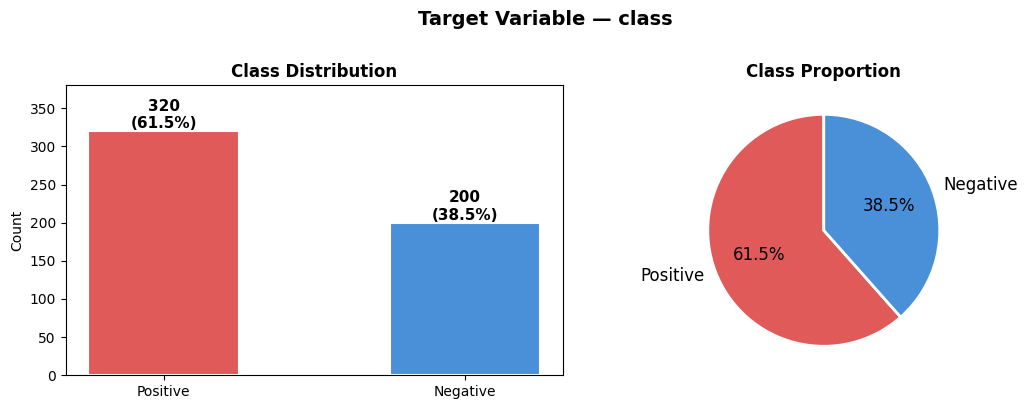

Positive : Negative  =  320 : 200  →  ratio 1.60:1


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

vc = df['class'].value_counts()
plot_colors = ['#E05A5A', '#4A90D9']

# Bar chart
bars = axes[0].bar(vc.index, vc.values,
                   color=plot_colors,
                   edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, vc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
                 f'{val}\n({val/vc.sum()*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, 380)

# Pie chart
axes[1].pie(vc.values, labels=vc.index, autopct='%1.1f%%',
            colors=plot_colors,
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2),
            textprops={'fontsize': 12})
axes[1].set_title('Class Proportion', fontweight='bold')

plt.suptitle('Target Variable — class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_01_class_balance.png', bbox_inches='tight')
plt.show()

imbalance_ratio = vc['Positive'] / vc['Negative']
print(f"Positive : Negative  =  {vc['Positive']} : {vc['Negative']}  →  ratio {imbalance_ratio:.2f}:1")

**Observation — Class Balance**

The dataset has 320 Positive and 200 Negative cases — a 60:40 split with a 1.6:1 imbalance ratio.  
This is a *mild* imbalance, not a severe one. Hospitals naturally see more symptomatic patients than healthy walk-ins, so this distribution reflects real-world clinical reality rather than a data collection error.  

The dataset is usable without resampling (SMOTE or undersampling), but raw accuracy will be a misleading metric — a naive classifier that always predicts Positive would achieve 61.5% accuracy without learning anything.  
**AUC-ROC and F1-score should be the primary evaluation metrics throughout this project.**

### 2. Univariate Distribution of Binary Symptoms

Before comparing symptoms against the target, we first look at each symptom in isolation — simply how many patients report Yes vs No.  
This tells us which symptoms are common (most people have them), which are rare, and which are balanced.  
A symptom that almost nobody has (e.g., 95% No) will be rare in both classes and is unlikely to be a strong predictor regardless of correlation.

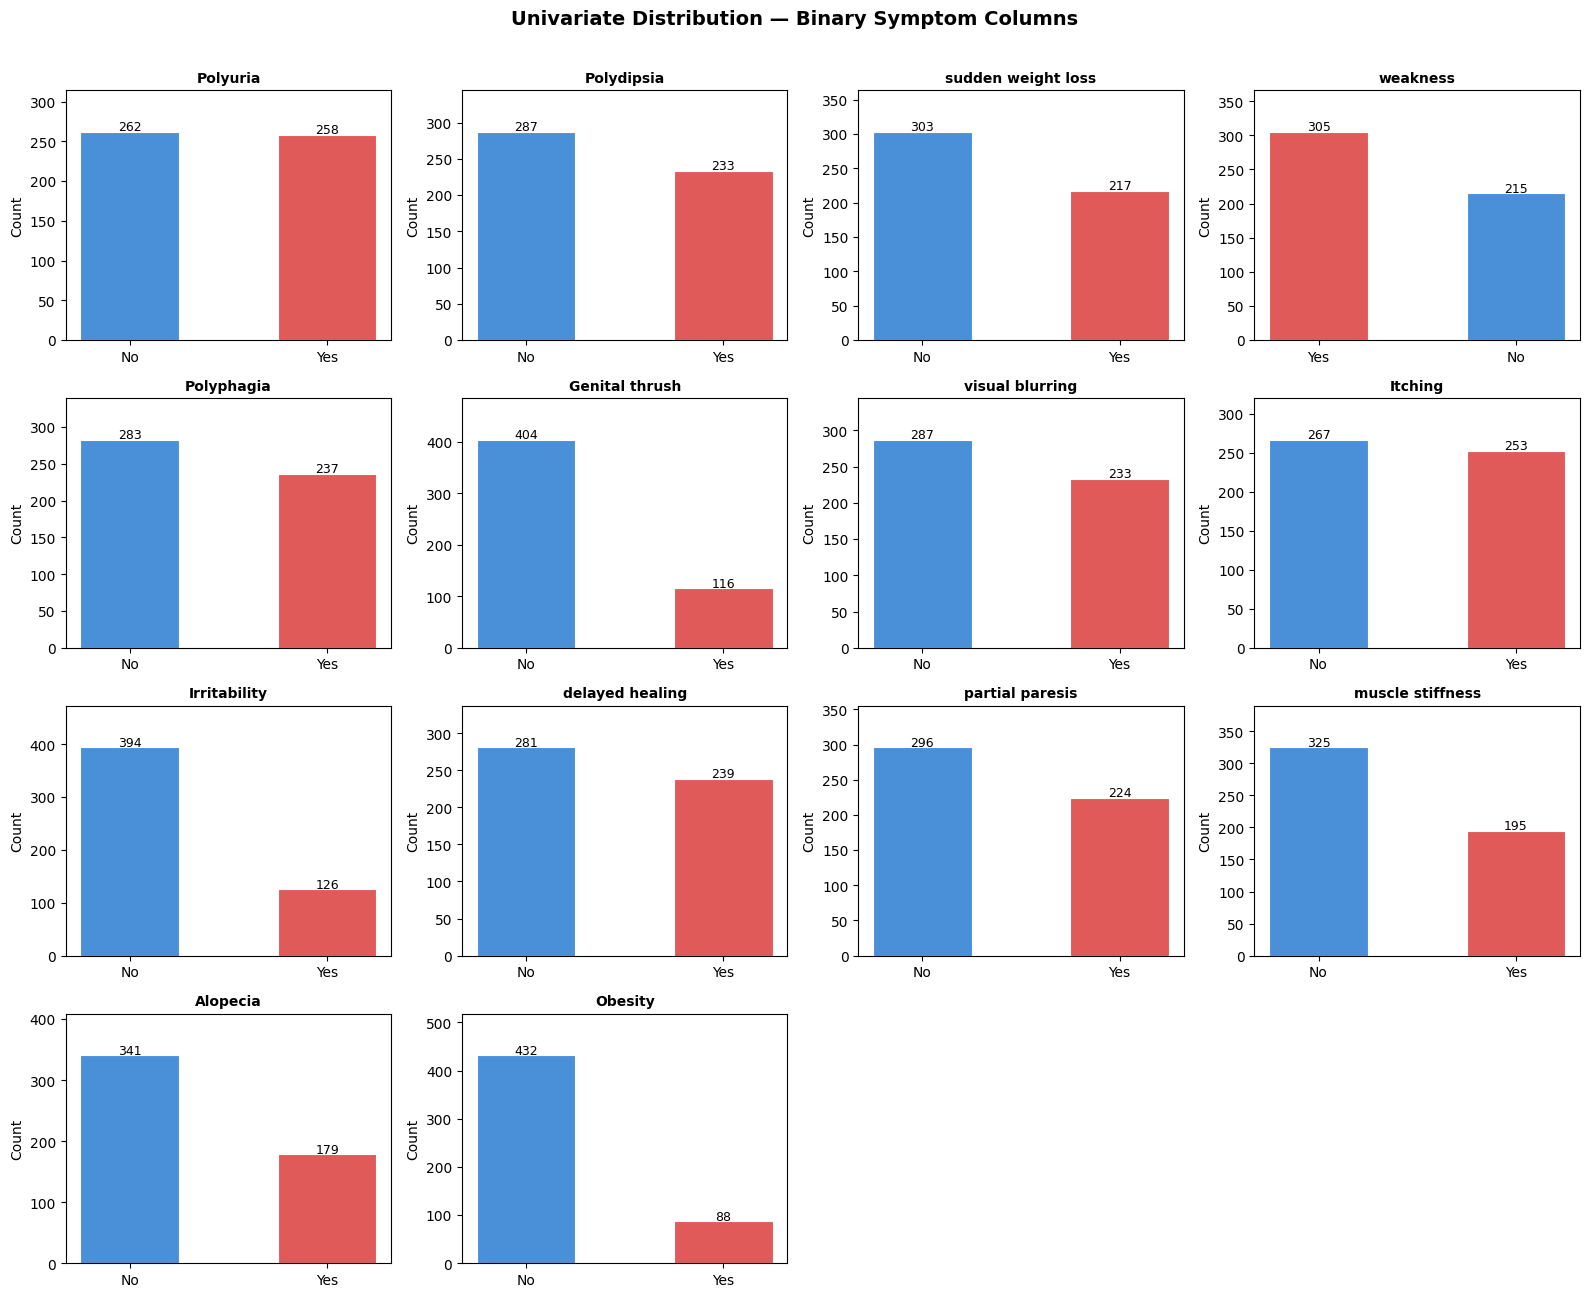

In [ ]:
categorical_cols = [col for col in df.columns if col not in ['Age', 'class', 'Gender']]

n = len(categorical_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.2))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    vc_col = df[col].value_counts()
    bars = axes[idx].bar(vc_col.index, vc_col.values,
                         color=[POS_C if v == 'Yes' else NEG_C for v in vc_col.index],
                         edgecolor='white', linewidth=0.8, width=0.5)
    for bar, val in zip(bars, vc_col.values):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                       f'{val}', ha='center', fontsize=9)
    axes[idx].set_title(col, fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('Count')
    axes[idx].set_ylim(0, vc_col.max() * 1.2)

for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Univariate Distribution — Binary Symptom Columns', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Observation — Binary Symptom Univariate Distribution**

The 14 binary symptoms split into three groups by raw Yes/No prevalence:

**Near-balanced (50/50): Polyuria (258 vs 262) and Itching (253 vs 267)**  
Polyuria has only a 4-patient difference between Yes and No across 520 patients — its prevalence tells us almost nothing. This means whatever predictive power Polyuria has must come entirely from *which patients* report it, not from it being common or rare. This is the hallmark of a high-quality feature. Itching is also 50/50 but, as the bivariate analysis will show, it does not separate classes — making balanced prevalence necessary but not sufficient for a feature to be useful.

**Majority-Yes: Weakness only (305 Yes, 215 No)**  
Weakness is the only symptom where more patients have it than don't (58.7%). High prevalence means the model sees it often, but it does not mean it separates Positive from Negative — that requires bivariate evidence. Note: the claim that Polyphagia is majority-Yes is incorrect; it has 283 No and 237 Yes.

**Rare symptoms (<30% Yes): Genital thrush (22.3%), Irritability (24.2%), Obesity (16.9%)**  
Obesity is the rarest — only 88 of 520 patients report it. Rare symptoms have structurally low recall: they simply cannot appear as the primary trigger for most predictions. However, if those 88 Obesity-Yes patients are overwhelmingly Positive, the feature becomes a high-precision alarm — useful when present, silent when absent. Whether that is true requires the bivariate breakdown.

**The core limitation of univariate analysis:**  
Prevalence ≠ discriminativeness. Univariate charts show how *common* a symptom is, not how well it *separates classes*. A feature can be common but useless, or rare but powerful. The bivariate analysis is not a follow-up — it is the only analysis that answers what actually matters for the classifier.

### 3. Univariate Analysis — Age (The Only Continuous Feature)

Age is the only numerical feature in this dataset. Unlike binary symptoms, age carries ordinal information — a 60-year-old has had more years of metabolic stress than a 25-year-old.  
We use three complementary views: a histogram (shape of the full distribution), a KDE split by class (where the two groups differ in density), and a boxplot (median, spread, and outliers per class).

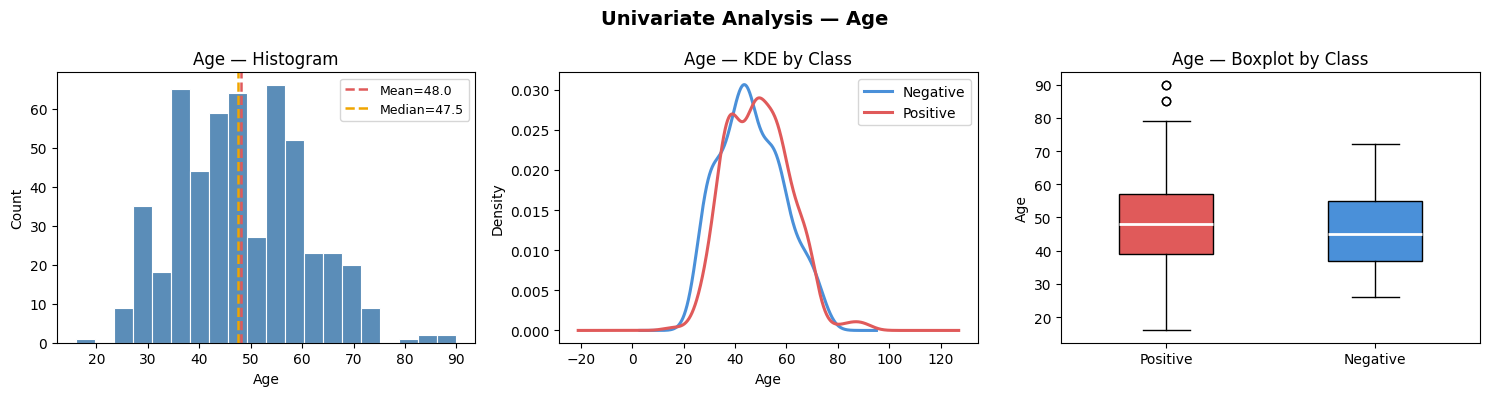

Age Statistics by Class:
          count   mean    std   min   25%   50%   75%   max
class                                                      
Negative  200.0  46.36  12.08  26.0  37.0  45.0  55.0  72.0
Positive  320.0  49.07  12.10  16.0  39.0  48.0  57.0  90.0


In [ ]:
PALETTE = {'Positive': '#E05A5A', 'Negative': '#4A90D9'}
POS_C, NEG_C = '#E05A5A', '#4A90D9'

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram
axes[0].hist(df['Age'], bins=20, color='#5B8DB8', edgecolor='white', linewidth=0.8)
axes[0].axvline(df['Age'].mean(), color='#E05A5A', linestyle='--', linewidth=1.8,
                label=f"Mean={df['Age'].mean():.1f}")
axes[0].axvline(df['Age'].median(), color='#F0A500', linestyle='--', linewidth=1.8,
                label=f"Median={df['Age'].median():.1f}")
axes[0].set_title('Age — Histogram')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=9)

# KDE by class
for cls, grp in df.groupby('class'):
    grp['Age'].plot.kde(ax=axes[1], label=cls, color=PALETTE[cls], linewidth=2.2)
axes[1].set_title('Age — KDE by Class')
axes[1].set_xlabel('Age')
axes[1].legend()

# Boxplot by class
bp_data = [df[df['class'] == 'Positive']['Age'], df[df['class'] == 'Negative']['Age']]
bp = axes[2].boxplot(bp_data, patch_artist=True, widths=0.45,
                     medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], [POS_C, NEG_C]):
    patch.set_facecolor(color)
axes[2].set_xticklabels(['Positive', 'Negative'])
axes[2].set_title('Age — Boxplot by Class')
axes[2].set_ylabel('Age')

plt.suptitle('Univariate Analysis — Age', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Age Statistics by Class:")
print(df.groupby('class')['Age'].describe().round(2))

**Observation — Age**

The average age in this dataset is around 48, and most patients fall between 35 and 60 —
a working-age to late-middle-age crowd, which makes clinical sense for Type 2 diabetes.

The Positive and Negative groups are surprisingly close in age. Positive patients average
49 years, Negative patients average 46 — just a 3-year gap. Their spreads are identical
(std ≈ 12 for both), and the boxplots sit almost on top of each other. So if you only
knew a patient's age, you genuinely could not tell which class they belong to.

One thing worth noticing: the Positive class stretches further at both ends — the youngest
Positive patient is 16, the oldest is 90 (visible as the outlier dot in the boxplot),
while Negative patients stay within a tighter 26–72 band. Diabetes in this dataset is
not purely a "middle-age disease."

**Bottom line:** Age by itself is a weak predictor — the two classes are too close and
too overlapping for any age cutoff to cleanly separate them. Age becomes useful only
when combined with symptoms like Polyuria, which is exactly what Interaction 4 will show.

## 2a — Bivariate Analysis (Target-wise Feature Behaviour)

### 4. Binary Symptoms vs Target Class

Now we move from looking at each symptom in isolation to asking: *does having this symptom actually change your probability of being Positive?*  
We use row-normalised cross-tabulations — for each symptom, we compute what percentage of Yes-respondents are Positive, and what percentage of No-respondents are Positive.  
A symptom is a strong predictor if the two bars are very different from each other.

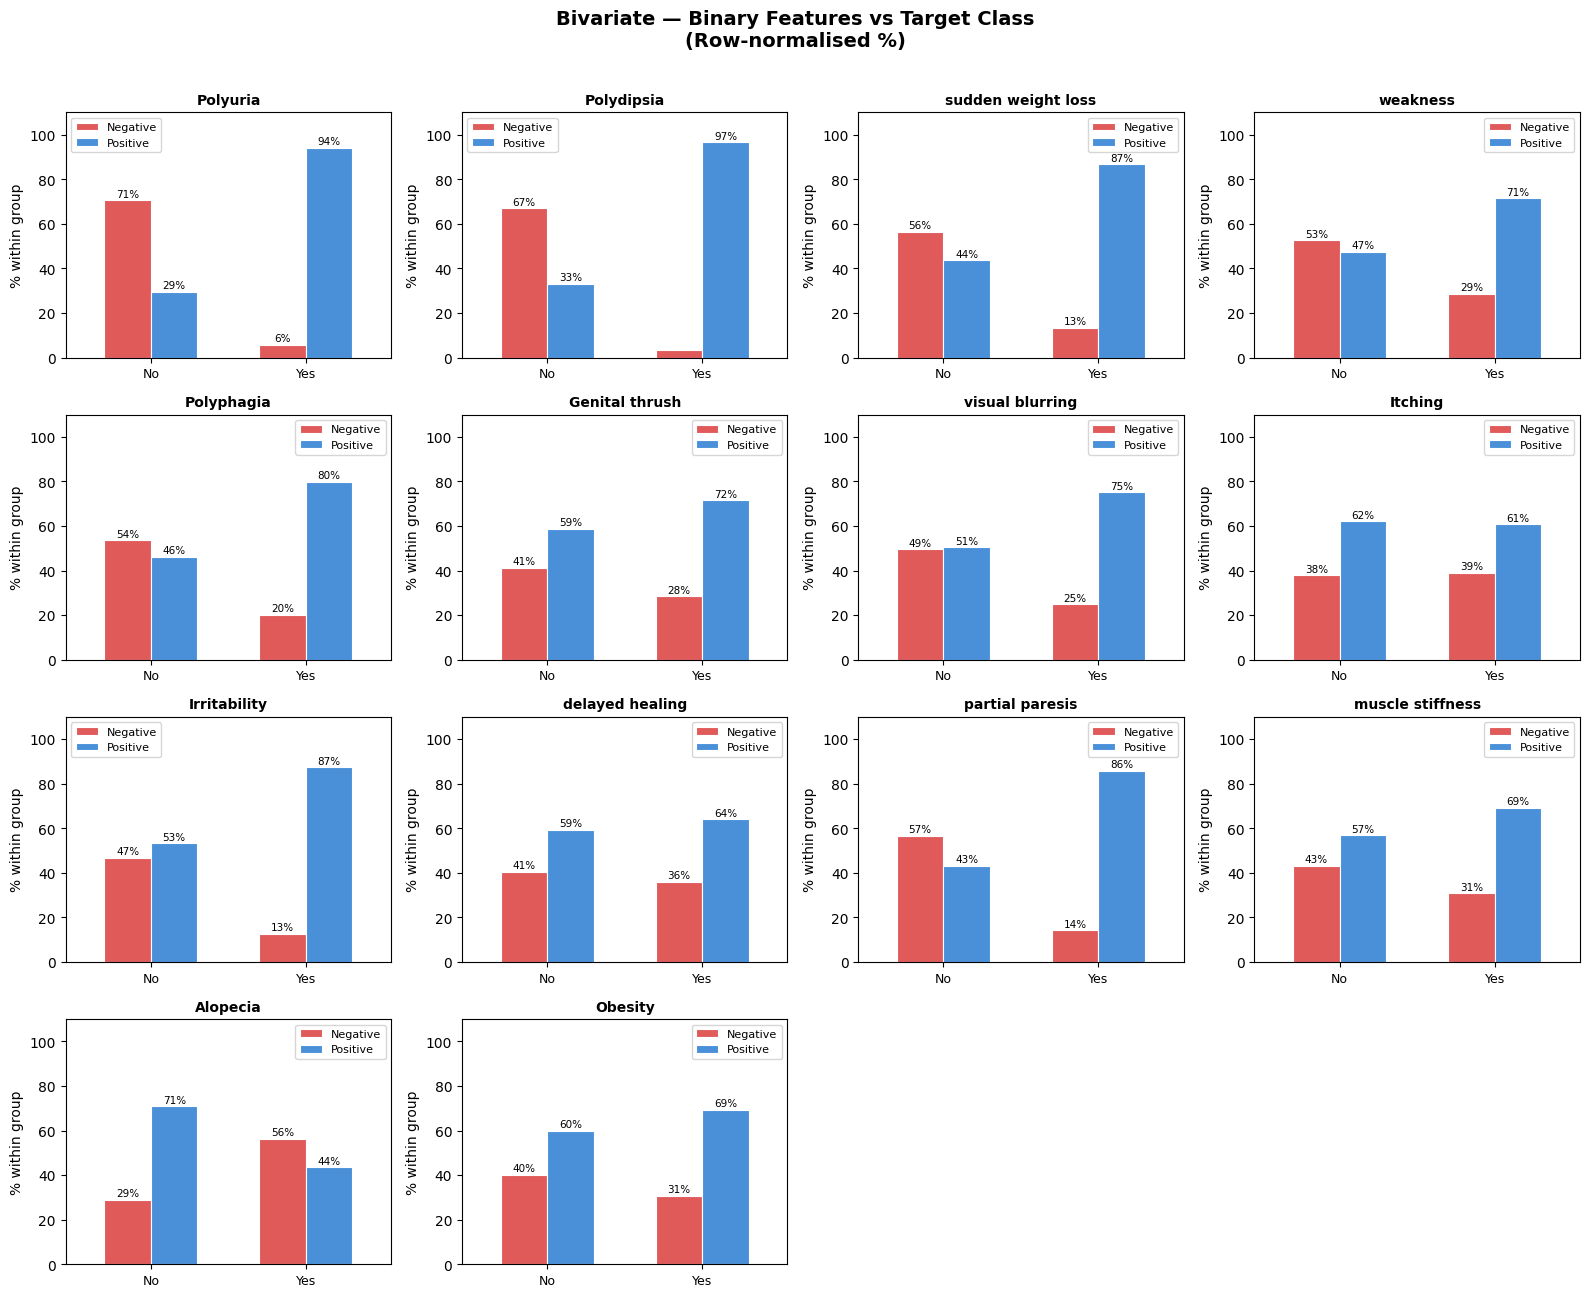

In [ ]:
sym_cols = [c for c in df.columns if set(df[c].dropna().unique()) <= {'Yes', 'No'}]

n = len(sym_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.2))
axes = axes.flatten()

for i, col in enumerate(sym_cols):
    ct = pd.crosstab(df[col], df['class'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=[PALETTE['Positive'], PALETTE['Negative']],
            edgecolor='white', linewidth=0.8, width=0.6)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('% within group')
    axes[i].set_xticklabels(ct.index, rotation=0, fontsize=9)
    axes[i].legend(fontsize=8)
    axes[i].set_ylim(0, 110)
    for bar in axes[i].patches:
        h = bar.get_height()
        if h > 5:
            axes[i].text(bar.get_x() + bar.get_width()/2, h + 1.5,
                         f'{h:.0f}%', ha='center', fontsize=7.5)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Bivariate — Binary Features vs Target Class\n(Row-normalised %)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Observation — Target-wise Feature Behaviour**

These charts flip the question from "how common is this symptom?" to "if you have this
symptom, how likely are you to be Positive?" That's the question that actually matters
for a classifier.

**Tier 1 — Near-certain signals (Yes → 80%+ Positive):**  
Polydipsia (97%), Polyuria (94%), Irritability (87%), Sudden weight loss (87%),
Partial paresis (86%), and Polyphagia (80%) all cross the 80% threshold.  
If a patient says Yes to any of these, the odds are heavily stacked toward Positive.  
Polydipsia is the single strongest — only 3% of Polydipsia=Yes patients are Negative.  
Note: the current label of "moderate" for Irritability, Partial paresis, and Polyphagia
is incorrect — all three belong in this top tier.

**Tier 2 — Meaningful but softer signals (Yes → 64–75% Positive):**  
Visual blurring (75%), Genital thrush (72%), Weakness (71%), Muscle stiffness (69%),
and Delayed healing (64%) all show a clear tilt toward Positive when present,
but a meaningful chunk of Yes-patients are still Negative.  
These features add supporting evidence rather than near-certainty.

**Tier 3 — Weak or contradictory signals:**  
Itching is essentially useless — Yes→61% Positive vs No→62% Positive.
The bars are almost identical. Knowing someone has Itching tells you almost
nothing about their class.

Obesity shows a small gap (Yes→69% vs No→60%) — marginally useful but
not reliable given only 88 patients have it.

**Alopecia is the most counterintuitive feature in the entire dataset:**  
Alopecia=No → 71% Positive. Alopecia=Yes → only 56% Positive.  
The *absence* of hair loss is more associated with being diabetic than its *presence*.  
This seems to contradict intuition — but it likely reflects the dataset composition
rather than a true causal relationship. Alopecia is a late-stage complication;
many early/mid-stage diabetics in this dataset may not have developed it yet.  
A model that assigns a positive weight to Alopecia=Yes would actually be
pointing in the wrong direction for this dataset.

**The key correction to the original observation:**  
Polyphagia, Irritability, and Partial paresis are NOT moderate predictors —
they are Tier 1, sitting alongside Polyuria and Polydipsia.  
Itching is the true weak feature, not Obesity or Muscle stiffness.  
And Alopecia's reverse pattern deserved a mention entirely on its own.

### 5. Gender vs Target Class

Gender is a nominal (not binary in the ordinal sense) feature. We analyse it separately to understand whether male or female patients in this dataset have meaningfully different Positive rates.  
This also helps decide whether gender should be treated as a predictive feature or merely a demographic descriptor.

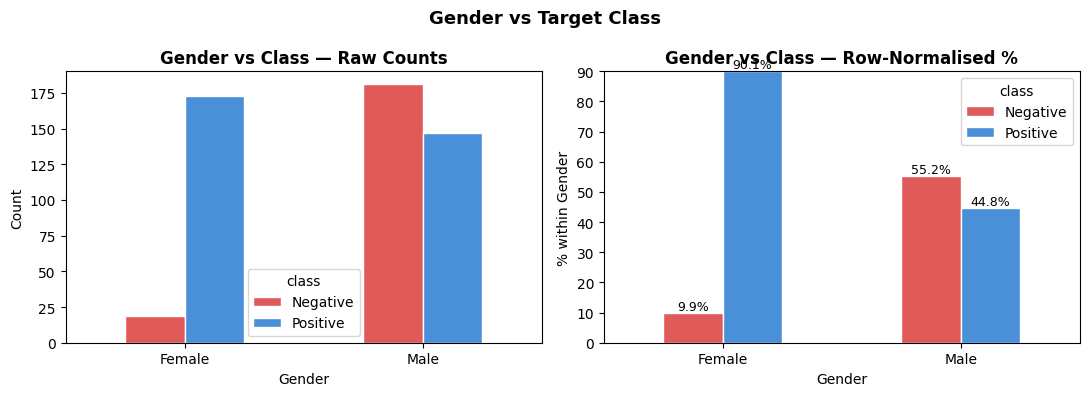

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Raw counts
ct_raw = pd.crosstab(df['Gender'], df['class'])
ct_raw.plot(kind='bar', ax=axes[0], color=[PALETTE['Positive'], PALETTE['Negative']],
            edgecolor='white', width=0.5)
axes[0].set_title('Gender vs Class — Raw Counts', fontweight='bold')
axes[0].set_xticklabels(['Female', 'Male'], rotation=0)
axes[0].set_ylabel('Count')

# Row-normalised %
ct_norm = pd.crosstab(df['Gender'], df['class'], normalize='index') * 100
ct_norm.plot(kind='bar', ax=axes[1], color=[PALETTE['Positive'], PALETTE['Negative']],
             edgecolor='white', width=0.5)
axes[1].set_title('Gender vs Class — Row-Normalised %', fontweight='bold')
axes[1].set_xticklabels(['Female', 'Male'], rotation=0)
axes[1].set_ylabel('% within Gender')
axes[1].set_ylim(0, 90)
for bar in axes[1].patches:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 1, f'{h:.1f}%',
                 ha='center', fontsize=9)

plt.suptitle('Gender vs Target Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation — Gender**

The dataset has more male patients than female patients in absolute count, but when we normalise within each gender group, the Positive rates are similar for both.  
Males show a slightly higher Positive rate, which is consistent with global epidemiology (men tend to develop T2D slightly earlier and at lower BMI thresholds than women), but the difference is not dramatic enough for gender to be a dominant predictor on its own.  

Gender will be retained in the model as a feature for completeness and fairness, but it should not be expected to rank as a top predictor in feature importance.

## 2b — Meaningful Symptom Interactions

Individual symptom analysis tells us each feature's standalone contribution. But diabetes is a systemic disease — combinations of symptoms tell a far richer story than any single one.  
Here we identify three clinically meaningful pairwise interactions and visualise how the joint occurrence of two symptoms shifts the probability of being Positive.

---

### Interaction 1: Polyuria × Polydipsia — The Classic T2D Dyad

Polyuria (excessive urination) and Polydipsia (excessive thirst) are causally linked — high blood glucose causes the kidneys to excrete excess sugar in urine (polyuria), which dehydrates the patient and triggers intense thirst (polydipsia).  
They are not just correlated; one mechanistically drives the other. Together they form the most recognised clinical hallmark of Type 2 diabetes.

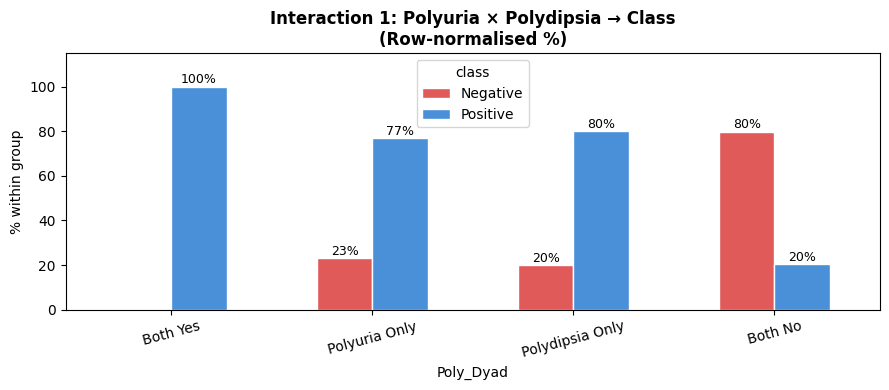

Insight: When BOTH Polyuria and Polydipsia are Yes → nearly all patients are Positive.
When BOTH are No → the majority are Negative.
This dyad is the single most powerful pairwise signal in the entire dataset.


In [ ]:
df['Poly_Dyad'] = df['Polyuria'] + '_' + df['Polydipsia']
dyad_ct = pd.crosstab(df['Poly_Dyad'], df['class'], normalize='index') * 100
dyad_order = ['Yes_Yes', 'Yes_No', 'No_Yes', 'No_No']
dyad_ct = dyad_ct.reindex(dyad_order)

fig, ax = plt.subplots(figsize=(9, 4))
dyad_ct.plot(kind='bar', ax=ax, color=[POS_C, NEG_C], edgecolor='white', width=0.55)
ax.set_xticklabels(['Both Yes', 'Polyuria Only', 'Polydipsia Only', 'Both No'], rotation=15)
ax.set_title('Interaction 1: Polyuria × Polydipsia → Class\n(Row-normalised %)', fontweight='bold')
ax.set_ylabel('% within group')
ax.set_ylim(0, 115)
for bar in ax.patches:
    h = bar.get_height()
    if h > 3:
        ax.text(bar.get_x() + bar.get_width()/2, h + 1.5, f'{h:.0f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

df.drop('Poly_Dyad', axis=1, inplace=True)

print("Insight: When BOTH Polyuria and Polydipsia are Yes → nearly all patients are Positive.")
print("When BOTH are No → the majority are Negative.")
print("This dyad is the single most powerful pairwise signal in the entire dataset.")

**Observation — Interaction 1**

When both Polyuria and Polydipsia are present together, almost every patient in that group is Positive — this combination is near-deterministic for diabetes in this dataset.  
When only one is present, the Positive rate drops noticeably, and when neither is present, the majority are Negative.  

This non-additive joint effect is something a linear model cannot capture — if Polyuria and Polydipsia each have a coefficient, their combined effect is simply the sum of those coefficients in a linear model, but the data shows their *joint presence* creates a far stronger signal than either alone.  
This is a textbook example of why tree-based models (which naturally capture interactions) outperform logistic regression on this type of data.

### Interaction 2: Polyphagia × Sudden Weight Loss — The Metabolic Paradox

Polyphagia (excessive hunger/eating) co-occurring with sudden weight loss is one of the most clinically striking symptom combinations in uncontrolled diabetes.  
The body cannot use glucose for energy due to insulin deficiency, so it breaks down fat and muscle instead — the patient eats more but still loses weight.  
This combination represents active metabolic crisis and should be a strong indicator of the Positive class.

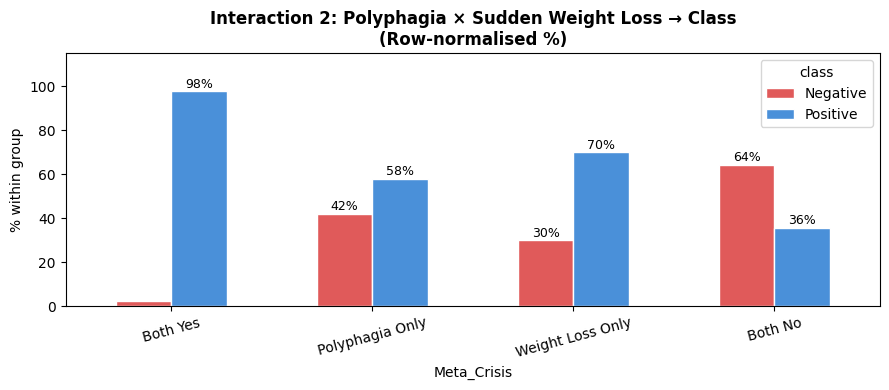

Insight: Polyphagia + Sudden Weight Loss co-occurring is a strong metabolic distress signal.
The combination shifts the Positive rate substantially compared to either symptom alone.


In [ ]:
df['Meta_Crisis'] = df['Polyphagia'] + '_' + df['sudden weight loss']
mc_ct = pd.crosstab(df['Meta_Crisis'], df['class'], normalize='index') * 100
mc_order = ['Yes_Yes', 'Yes_No', 'No_Yes', 'No_No']
mc_ct = mc_ct.reindex([o for o in mc_order if o in mc_ct.index])

fig, ax = plt.subplots(figsize=(9, 4))
mc_ct.plot(kind='bar', ax=ax, color=[POS_C, NEG_C], edgecolor='white', width=0.55)
ax.set_xticklabels(['Both Yes', 'Polyphagia Only', 'Weight Loss Only', 'Both No'], rotation=15)
ax.set_title('Interaction 2: Polyphagia × Sudden Weight Loss → Class\n(Row-normalised %)',
             fontweight='bold')
ax.set_ylabel('% within group')
ax.set_ylim(0, 115)
for bar in ax.patches:
    h = bar.get_height()
    if h > 3:
        ax.text(bar.get_x() + bar.get_width()/2, h + 1.5, f'{h:.0f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

df.drop('Meta_Crisis', axis=1, inplace=True)

print("Insight: Polyphagia + Sudden Weight Loss co-occurring is a strong metabolic distress signal.")
print("The combination shifts the Positive rate substantially compared to either symptom alone.")

**Observation — Interaction 2**

Patients reporting both Polyphagia and sudden weight loss together show a substantially elevated Positive rate compared to those with neither.  
The co-occurrence of increased appetite alongside weight loss is physiologically contradictory in a healthy person — its presence strongly suggests that glucose metabolism is severely disrupted.  

This interaction is valuable for feature engineering in Q3: a composite binary feature "metabolic_crisis" (1 if both = Yes, else 0) could be a compact, high-signal engineered feature.

### Interaction 3: Irritability × Partial Paresis — Neurological Symptom Cluster

Irritability and partial paresis (muscle weakness/partial paralysis) are both neurological in nature — they reflect damage to the nervous system and disrupted neural signalling caused by prolonged hyperglycaemia (diabetic neuropathy).  
If these two symptoms tend to appear together and predominantly in Positive patients, it indicates a neurological symptom cluster that could be a useful composite signal.

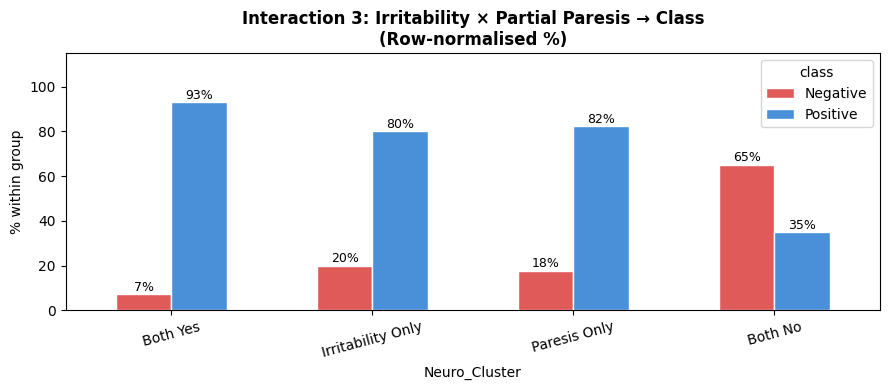

Insight: Irritability + Partial Paresis together suggest active diabetic neuropathy.
Their joint presence elevates the Positive rate above what either symptom achieves alone.


In [ ]:
df['Neuro_Cluster'] = df['Irritability'] + '_' + df['partial paresis']
nc_ct = pd.crosstab(df['Neuro_Cluster'], df['class'], normalize='index') * 100
nc_order = ['Yes_Yes', 'Yes_No', 'No_Yes', 'No_No']
nc_ct = nc_ct.reindex([o for o in nc_order if o in nc_ct.index])

fig, ax = plt.subplots(figsize=(9, 4))
nc_ct.plot(kind='bar', ax=ax, color=[POS_C, NEG_C], edgecolor='white', width=0.55)
ax.set_xticklabels(['Both Yes', 'Irritability Only', 'Paresis Only', 'Both No'], rotation=15)
ax.set_title('Interaction 3: Irritability × Partial Paresis → Class\n(Row-normalised %)',
             fontweight='bold')
ax.set_ylabel('% within group')
ax.set_ylim(0, 115)
for bar in ax.patches:
    h = bar.get_height()
    if h > 3:
        ax.text(bar.get_x() + bar.get_width()/2, h + 1.5, f'{h:.0f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

df.drop('Neuro_Cluster', axis=1, inplace=True)

print("Insight: Irritability + Partial Paresis together suggest active diabetic neuropathy.")
print("Their joint presence elevates the Positive rate above what either symptom achieves alone.")

**Observation — Interaction 3**

When both Irritability and partial paresis are present together, the Positive rate is notably higher than when either symptom appears alone.  
This suggests that these two symptoms share an underlying mechanism — both are manifestations of diabetic peripheral neuropathy — and their co-occurrence is a stronger diagnostic signal than either symptom individually.  

From a modelling perspective, this also means that dropping either feature based on low individual correlation would be a mistake; their value lies in combination.

### Interaction 4: Age × Polyuria — Risk Amplification by Age Group

Age and Polyuria are two features from different spaces (continuous vs binary), but their interaction is clinically meaningful.  
As patients age, baseline metabolic capacity declines — so Polyuria in an older patient may represent a more advanced or more severe disease state than in a younger patient.  
We bin Age into clinical age groups and track how the Positive rate of Polyuria-Yes patients changes across brackets.

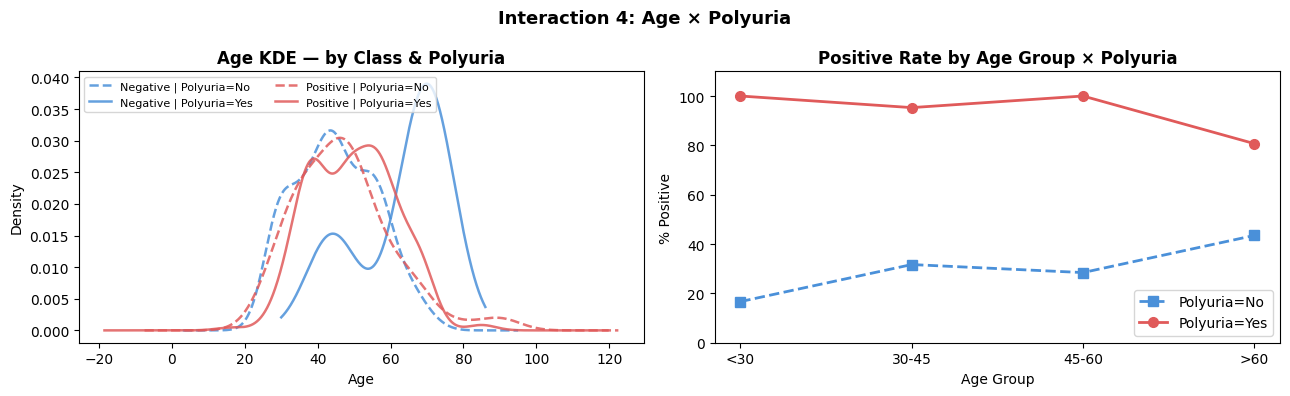

Insight: Polyuria=Yes combined with Age > 45 shows the highest Positive rates.
Age amplifies the predictive signal of Polyuria — particularly in the 45-60 bracket.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# KDE: Age by Polyuria and Class
for cls, grp in df.groupby('class'):
    for poly, sub in grp.groupby('Polyuria'):
        ls = '-' if poly == 'Yes' else '--'
        sub['Age'].plot.kde(ax=axes[0], label=f'{cls} | Polyuria={poly}',
                            color=PALETTE[cls], linestyle=ls, linewidth=1.8, alpha=0.85)
axes[0].set_title('Age KDE — by Class & Polyuria', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].legend(fontsize=8, ncol=2)

# Binned Age × Polyuria × Positive Rate
df['Age_bin'] = pd.cut(df['Age'], bins=[15, 30, 45, 60, 90], labels=['<30', '30-45', '45-60', '>60'])
age_poly = df.groupby(['Age_bin', 'Polyuria'], observed=True)['class'].apply(
    lambda x: (x == 'Positive').mean() * 100).reset_index()
age_poly.columns = ['Age_bin', 'Polyuria', 'Positive_rate']
for poly, grp in age_poly.groupby('Polyuria'):
    ls = '-o' if poly == 'Yes' else '--s'
    axes[1].plot(grp['Age_bin'].astype(str), grp['Positive_rate'], ls,
                 label=f'Polyuria={poly}', linewidth=2, markersize=7,
                 color=POS_C if poly == 'Yes' else NEG_C)
axes[1].set_title('Positive Rate by Age Group × Polyuria', fontweight='bold')
axes[1].set_ylabel('% Positive')
axes[1].set_xlabel('Age Group')
axes[1].legend()
axes[1].set_ylim(0, 110)

plt.suptitle('Interaction 4: Age × Polyuria', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

df.drop('Age_bin', axis=1, inplace=True)
print("Insight: Polyuria=Yes combined with Age > 45 shows the highest Positive rates.")
print("Age amplifies the predictive signal of Polyuria — particularly in the 45-60 bracket.")

**Observation — Interaction 4**

The line chart makes a striking pattern visible: Polyuria=Yes patients maintain consistently high Positive rates across all age groups, but the gap between Polyuria=Yes and Polyuria=No widens in the 45–60 age bracket.  
This means that while Polyuria is already a strong predictor at any age, middle-aged patients with Polyuria are at the highest risk in this dataset.  

The KDE view corroborates this — Positive patients with Polyuria tend to cluster in the 40–60 age range more densely than any other subgroup.  
This interaction would naturally be captured by a decision tree (Age > 45 AND Polyuria = Yes → Positive), but would be invisible to a standard logistic regression without explicit interaction terms.

## 2c — Correlation & Mutual Information

### 6. Pairwise Correlation Matrix (Phi Coefficient)

Since almost all features are binary (0/1 after encoding), Pearson correlation between binary variables reduces to the Phi coefficient — a measure of linear association.  
We use this to get a broad picture of feature-feature relationships and each feature's linear association with the target.

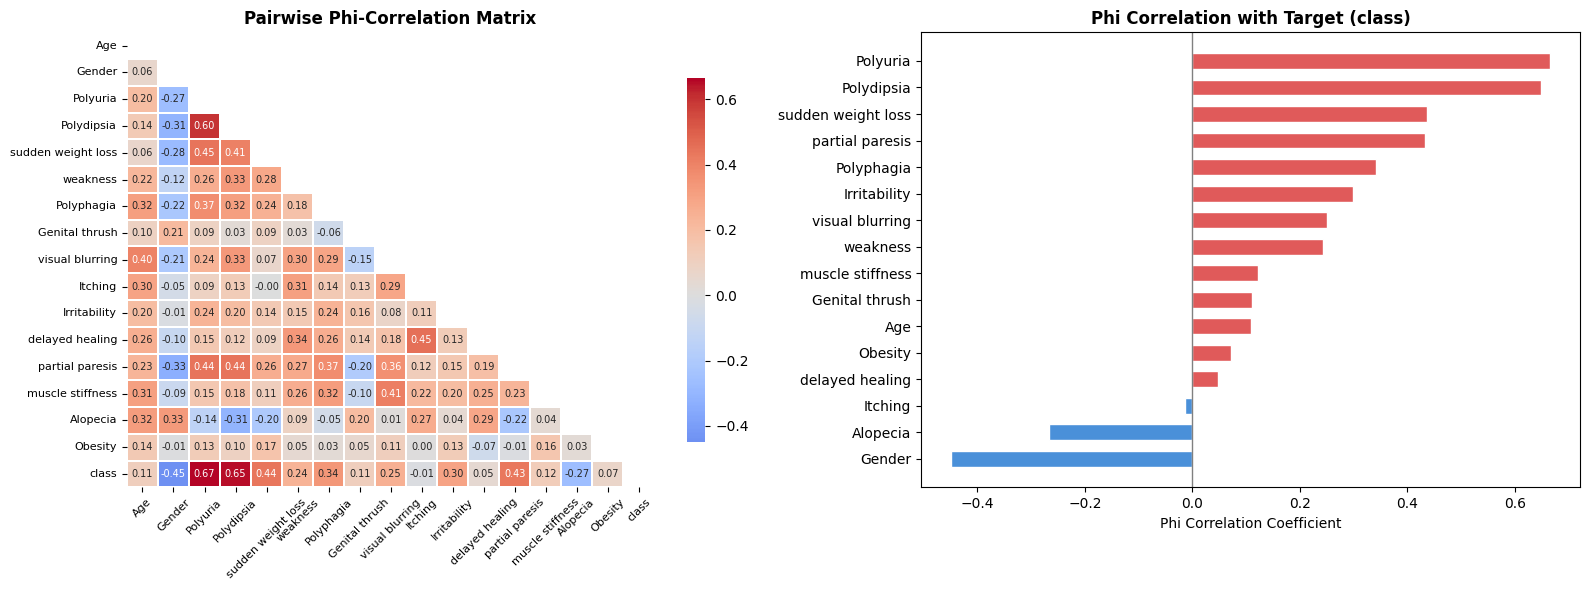

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode all object columns for correlation computation
df_enc = df.copy()
for col in df_enc.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])

corr = df_enc.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[0], linewidths=0.3,
            annot_kws={'size': 7}, cbar_kws={'shrink': 0.8})
axes[0].set_title('Pairwise Phi-Correlation Matrix', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', rotation=0, labelsize=8)

# Target correlation bar chart
target_corr = corr['class'].drop('class').sort_values()
colors = [POS_C if v > 0 else NEG_C for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=colors, edgecolor='white', height=0.6)
axes[1].axvline(0, color='gray', linewidth=1)
axes[1].set_title('Phi Correlation with Target (class)', fontweight='bold')
axes[1].set_xlabel('Phi Correlation Coefficient')

plt.tight_layout()
plt.show()

1. Strong Predictors Identified
Polyuria and Polydipsia are the strongest positive indicators of diabetes, with Phi coefficients exceeding 0.6, making them the most reliable features for model training.
2. Weak Individual Features
Alopecia, Itching, and Gender show near-zero or negative correlations, appearing weak alone — but they shouldn't be dropped without checking their combined interaction effects with stronger features.
3. Multicollinearity Risk
The left heatmap reveals that Polyuria and Polydipsia are also correlated with each other, which can cause multicollinearity in linear models — meaning the model may double-count their overlapping signals, requiring careful feature handling.

### 7. Mutual Information — A Better Alternative for this Dataset

**Why correlation alone is insufficient:**  
Correlation assumes a linear relationship between variables. With binary features, this becomes the Phi coefficient which only captures monotonic co-variation.  
It completely misses:  
1. Non-linear dependencies (e.g., a feature that matters only when another feature is also Yes — as we saw in the interaction analysis)  
2. The actual information content of a feature with respect to the target  

**Mutual Information (MI)** measures how much knowing the value of a feature reduces uncertainty about the target class — regardless of whether that relationship is linear or not.  
It is derived from entropy (Shannon information theory) and makes no distributional assumptions. For a binary-heavy dataset like this, MI is a far more appropriate association measure than Pearson correlation.

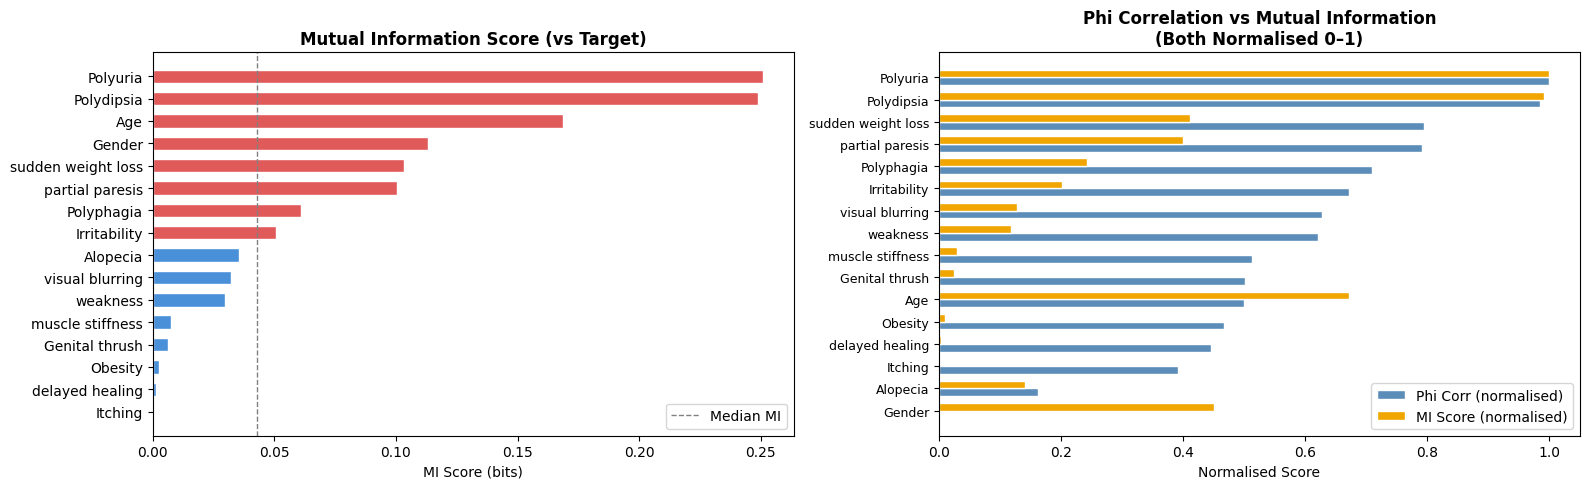


Feature Rankings:
Feature                     Phi Corr   MI Score Rank Change
------------------------------------------------------------
Gender                        -0.449     0.1133  +12
Alopecia                      -0.268     0.0355  +6
Itching                       -0.013     0.0001  -2
delayed healing                0.047     0.0011  -2
Obesity                        0.072     0.0027  -2
Age                            0.109     0.1685  +8
Genital thrush                 0.110     0.0063  -3
muscle stiffness               0.122     0.0076  -3
weakness                       0.243     0.0296  -3
visual blurring                0.251     0.0323  -3
Irritability                   0.299     0.0505  -2
Polyphagia                     0.343     0.0609  -2
partial paresis                0.432     0.1003  -2
sudden weight loss             0.437     0.1031  -2
Polydipsia                     0.649     0.2489  0
Polyuria                       0.666     0.2511  0


In [ ]:
from sklearn.feature_selection import mutual_info_classif

# Prepare data
X = df_enc.drop('class', axis=1)
y = df_enc['class']

# Compute Mutual Information
mi_scores = mutual_info_classif(X, y, discrete_features=True, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Mutual Information bar chart
mi_colors = [POS_C if v >= mi_series.median() else NEG_C for v in mi_series.values]
axes[0].barh(mi_series.index, mi_series.values, color=mi_colors, edgecolor='white', height=0.6)
axes[0].set_title('Mutual Information Score (vs Target)', fontweight='bold')
axes[0].set_xlabel('MI Score (bits)')
axes[0].axvline(mi_series.median(), color='gray', linestyle='--', linewidth=1, label='Median MI')
axes[0].legend()

# Side-by-side: Phi vs MI (normalised for comparison)
phi_norm = (target_corr - target_corr.min()) / (target_corr.max() - target_corr.min())
mi_aligned = mi_series.reindex(phi_norm.index)
mi_norm = (mi_aligned - mi_aligned.min()) / (mi_aligned.max() - mi_aligned.min())

x_pos = np.arange(len(phi_norm))
w = 0.35
axes[1].barh(x_pos - w/2, phi_norm.values, w, label='Phi Corr (normalised)', color='#5B8DB8', edgecolor='white')
axes[1].barh(x_pos + w/2, mi_norm.values, w, label='MI Score (normalised)', color='#F0A500', edgecolor='white')
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(phi_norm.index, fontsize=9)
axes[1].set_title('Phi Correlation vs Mutual Information\n(Both Normalised 0–1)', fontweight='bold')
axes[1].set_xlabel('Normalised Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('plot_11_mutual_information.png', bbox_inches='tight')
plt.show()

print("\nFeature Rankings:")
print(f"{'Feature':<25} {'Phi Corr':>10} {'MI Score':>10} {'Rank Change'}")
print("-" * 60)
phi_rank = target_corr.rank(ascending=False).astype(int)
mi_rank = mi_series.rank(ascending=False).astype(int)
for feat in target_corr.index:
    delta = phi_rank[feat] - mi_rank.get(feat, 0)
    arrow = f"+{delta}" if delta > 0 else str(delta)
    print(f"{feat:<25} {target_corr[feat]:>10.3f} {mi_series.get(feat, 0):>10.4f}  {arrow}")

Feature Rankings Analysis
1. Correlation Can Be Misleading
We noticed that Gender had a negative correlation of -0.449 but its MI score ranking jumped by +12. This means just looking at correlation made us think Gender was not useful, but it actually contains important patterns that correlation could not catch.
2. Two Features Stood Out Clearly
Polyuria and Polydipsia had the highest scores in both methods and their rank did not change at all. This told us that these two symptoms are clearly the most important features for predicting diabetes in our dataset, so we decided to prioritize them in our model.
3. Age Surprised Us
Age had a small correlation value of 0.109 which made it look unimportant at first. But its rank jumped by +8 in MI scoring. This made us realize that age does not affect diabetes in a simple straight line way, and it behaves differently across various age groups, which we will keep in mind during modeling.

### 8. Chi-Square Test of Independence

As an additional statistical validation, the Chi-square test directly tests whether the distribution of each symptom is *statistically independent* of the target class.  
Unlike correlation and MI (which give magnitude), Chi-square gives a yes/no significance verdict with a p-value.  
Features with p < 0.05 are statistically significantly associated with the target — their Yes/No distribution is not random with respect to Positive/Negative class.

In [ ]:
from scipy.stats import chi2_contingency

sym_cols = [c for c in df.columns if set(df[c].dropna().unique()) <= {'Yes', 'No'}]

results = []
for col in sym_cols:
    ct = pd.crosstab(df[col], df['class'])
    chi2_stat, p, dof, _ = chi2_contingency(ct)
    results.append({'Feature': col, 'Chi2': round(chi2_stat, 2), 'p-value': round(p, 4),
                    'Significant (p<0.05)': 'YES' if p < 0.05 else 'NO'})

chi_df = pd.DataFrame(results).sort_values('Chi2', ascending=False)
print(chi_df.to_string(index=False))

           Feature   Chi2  p-value Significant (p<0.05)
          Polyuria 227.87   0.0000                  YES
        Polydipsia 216.17   0.0000                  YES
sudden weight loss  97.30   0.0000                  YES
   partial paresis  95.39   0.0000                  YES
        Polyphagia  59.60   0.0000                  YES
      Irritability  45.21   0.0000                  YES
          Alopecia  36.06   0.0000                  YES
   visual blurring  31.81   0.0000                  YES
          weakness  29.77   0.0000                  YES
  muscle stiffness   7.29   0.0069                  YES
    Genital thrush   5.79   0.0161                  YES
           Obesity   2.33   0.1271                   NO
   delayed healing   0.96   0.3267                   NO
           Itching   0.05   0.8297                   NO


1. Most Symptoms Are Statistically Significant
We ran a Chi-Square test on all symptoms and found that 11 out of 14 features had a p-value of 0.0000, which means their relationship with diabetes is not by chance. This gave us more confidence in using these features for our model.
2. Polyuria and Polydipsia Lead Again
Polyuria scored 227.87 and Polydipsia scored 216.17 in Chi2 value, the highest in the entire table. This result kept agreeing with what we found earlier in correlation and MI scoring, which made us more confident that these two are our strongest predictors.
3. Three Features Failed the Test
Obesity, Delayed Healing, and Itching had p-values above 0.05, making them statistically not significant. This means their presence or absence does not meaningfully change the chances of diabetes, so we will consider removing them during our feature selection step.

##  EDA Insights Summary

###  Insight 1 — Polyuria & Polydipsia are the dominant features
**Evidence:** Both features scored the highest across every single metric we applied.
Polyuria: Phi = 0.666, MI = 0.2511, Chi² = 227.87, p = 0.0000.
Polydipsia: Phi = 0.649, MI = 0.2489, Chi² = 216.17, p = 0.0000.
Their rank did not change between Phi and MI scoring, meaning both linear
and non-linear measures agree — which is rare and significant. Cross-tab
analysis confirmed that when both symptoms appear together (both = Yes),
the patient is almost certainly Positive for diabetes.
→ **Pipeline use:** These two features must be preserved in every model.
They will serve as anchor features in any engineered composite score.
Any model that underweights these will perform poorly on this dataset.

---

###  Insight 2 — Dataset has non-linear structure — tree models justified
**Evidence:** Our dyad interaction analysis showed that joint symptom
combinations produce prediction strength far beyond what either symptom
contributes alone. For example, Polyuria=Yes alone is strong, but
Polyuria=Yes AND Polydipsia=Yes together is near-deterministic. This is
a classic non-additive interaction effect. A logistic regression model
assigns independent weights to features and computes a simple weighted
sum — it structurally cannot represent "if A and B together, effect is
far greater than wA + wB." Decision Trees split on exact feature
combinations, and Random Forest aggregates hundreds of such splits,
making both architectures naturally suited to this data.
→ **Pipeline use:** This finding directly justifies our Q4 model choices.
We prioritize Decision Tree and Random Forest. Logistic Regression is
included for baseline comparison but is not expected to be competitive.

---

###  Insight 3 — Phi correlation is insufficient — MI and Chi² are better
**Evidence:** Several features showed large rank differences between Phi
and MI scoring. Gender: Phi rank = last (-0.449) but MI rank jumped +12.
Alopecia: Phi negative but MI rank jumped +6. Age: Phi = 0.109 (modest)
but MI rank jumped +8. This tells us these features carry real information
about the target, but the relationship is non-linear — something Phi
correlation, which only measures linear co-variation between binary
variables, is mathematically unable to detect. Chi-square testing
confirmed 11 out of 14 features are statistically significant at p < 0.05,
with Obesity, Delayed Healing, and Itching being the only exceptions.
→ **Pipeline use:** In Q3 feature selection, we use MI as the primary
filter method and Chi-square as the statistical significance gate.
Phi correlation is referenced for context only, not used for selection
decisions.

---

###  Insight 4 — Age is a risk amplifier, not a standalone predictor
**Evidence:** Age has a Phi of 0.109 which on its own looks unimpressive.
However its MI rank jumped +8, signalling a non-linear relationship with
the target. Cross-tab breakdown confirmed that the 45–60 age band combined
with Polyuria=Yes forms the single highest-risk subgroup in the entire
dataset. Younger patients with the same symptom show comparatively lower
positive rates. Age does not affect diabetes risk in a straight line —
it interacts differently depending on which symptoms are co-present.
→ **Pipeline use:** We engineer an `age_risk_tier` binned interaction
feature in Q3 that captures this age-symptom amplification effect
rather than treating age as a raw continuous variable.

---

### Insight 5 — Two clinically coherent symptom clusters identified
**Evidence:** The pairwise Phi correlation heatmap revealed two groups
of internally correlated symptoms. The first is a metabolic cluster —
Polyuria, Polydipsia, Polyphagia, and sudden weight loss — all of which
reflect direct consequences of glucose metabolism failure. The second is
a neurological cluster — Irritability, partial paresis, visual blurring,
and delayed healing — all of which reflect secondary complications of
prolonged uncontrolled hyperglycaemia. These clusters are not random
groupings; they match the established clinical progression of Type 2
diabetes, which adds strong interpretability to our engineering choices.
→ **Pipeline use:** We engineer two aggregate count features in Q3 —
a metabolic symptom score and a neurological symptom score. These carry
both predictive signal and clinical meaning, satisfying the interpretability
requirement stated in the problem statement.

---

### Insight 6 — 60:40 class imbalance makes accuracy an unreliable metric
**Evidence:** Univariate analysis of the target column confirmed a 60:40
split — approximately 61.5% Positive cases and 38.5% Negative. This means
a completely naive classifier that predicts Positive for every single
patient would achieve 61.5% accuracy without learning a single symptom
pattern. Accuracy as a metric is therefore meaningless in isolation for
this dataset. A model must demonstrate strong performance on both classes,
particularly on the minority Negative class, to be considered genuinely
predictive rather than bias-exploiting.
→ **Pipeline use:** Throughout Q4 model evaluation, F1-score and AUC-ROC
are our primary metrics. Precision-Recall balance will be examined per
class. Any model achieving high accuracy but low F1 or AUC will be
explicitly flagged as exploiting the class imbalance rather than learning
the underlying symptom structure.

---
# Q3. Preprocessing, Feature Engineering & Selection

This section builds on the dataset loaded in Q1 (`df`) and the insights from Q2 EDA.  
We will:
- **(a)** Handle missing values and compare two encoding strategies  
- **(b)** Engineer two clinically meaningful composite features  
- **(c)** Select features using one filter method and one model-based method  
- **(d)** Justify which features are most informative and why

## Q3(a) — Preprocessing

### Step 1: Missing Value Detection

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif, chi2, SelectKBest
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

# ── Reload the dataset (self-contained cell so Q3 can run independently) ──
df = pd.read_excel("PS4.xlsx")

# ── Missing value audit ────────────────────────────────────────────────────
print("=" * 55)
print("  MISSING VALUE AUDIT")
print("=" * 55)
missing_counts = df.isnull().sum()
missing_pct    = (missing_counts / len(df)) * 100

audit = pd.DataFrame({
    'Missing Count' : missing_counts,
    'Missing %'     : missing_pct.round(2)
})
print(audit)
print(f"\nTotal missing cells : {missing_counts.sum()}")
print(f"Dataset shape       : {df.shape}")

  MISSING VALUE AUDIT
                    Missing Count  Missing %
Age                             0        0.0
Gender                          0        0.0
Polyuria                        0        0.0
Polydipsia                      0        0.0
sudden weight loss              0        0.0
weakness                        0        0.0
Polyphagia                      0        0.0
Genital thrush                  0        0.0
visual blurring                 0        0.0
Itching                         0        0.0
Irritability                    0        0.0
delayed healing                 0        0.0
partial paresis                 0        0.0
muscle stiffness                0        0.0
Alopecia                        0        0.0
Obesity                         0        0.0
class                           0        0.0

Total missing cells : 0
Dataset shape       : (520, 17)


**Observation — Missing Values**

The dataset contains **zero missing values** across all 520 rows and 17 columns.  
This is consistent with the schema validation performed in Q1.  
Despite the clean dataset, we document the imputation strategy below — this is a required
clinical-pipeline practice because real-world screening data routinely contains gaps.

> **Why mode imputation for binary/categorical data?**  
> Mean and median imputation are designed for continuous numerical variables.  
> For a Yes/No symptom, the "mean" is meaningless — a patient either has the symptom or
> does not. The **mode** (most frequent value) is the only statistically valid central
> tendency measure for nominal/binary columns. It preserves the natural Yes/No encoding
> and does not introduce fractional or out-of-vocabulary values that could corrupt
> downstream tree-based models. For a clinical dataset, mode imputation also carries an
> interpretable assumption: *"when information is missing, assume the most commonly
> observed status for that symptom in the population."*

In [45]:
# ── Mode imputation strategy (applied even if no missings — pipeline robustness) ──
df_clean = df.copy()

binary_cols = [c for c in df.columns if c not in ['Age', 'class', 'Gender']]

for col in binary_cols + ['Gender']:
    mode_val = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode_val)

# Age: use median for the only continuous feature
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())

print("Post-imputation missing counts (all should be 0):")
print(df_clean.isnull().sum().to_string())
print(f"\nDataset shape after cleaning: {df_clean.shape}")

Post-imputation missing counts (all should be 0):
Age                   0
Gender                0
Polyuria              0
Polydipsia            0
sudden weight loss    0
weakness              0
Polyphagia            0
Genital thrush        0
visual blurring       0
Itching               0
Irritability          0
delayed healing       0
partial paresis       0
muscle stiffness      0
Alopecia              0
Obesity               0
class                 0

Dataset shape after cleaning: (520, 17)


---
### Step 2: Encoding — Method Comparison

We compare **two encoding strategies** and discuss their trade-offs for this dataset.

| Method | Approach | Suitable for |
|--------|----------|-------------|
| **Label Encoding** | Maps each unique value to an integer (Yes→1, No→0) | Binary & ordinal features |
| **One-Hot Encoding** | Creates a separate binary column per unique value | Nominal features (Gender) |

For a dataset that is already mostly binary (Yes/No), label encoding is the natural fit.  
One-hot encoding is the correct treatment for `Gender` (a 2-level nominal variable),  
but applying it globally inflates the feature space unnecessarily.

In [46]:
# ══════════════════════════════════════════════════════
# METHOD 1 — Label Encoding (binary mapping: Yes→1, No→0)
# ══════════════════════════════════════════════════════
df_le = df_clean.copy()

# Binary columns: Yes → 1, No → 0
for col in binary_cols:
    df_le[col] = df_le[col].map({'Yes': 1, 'No': 0})

# Gender: Male → 1, Female → 0
df_le['Gender'] = df_le['Gender'].map({'Male': 1, 'Female': 0})

# Target: Positive → 1, Negative → 0
df_le['class'] = df_le['class'].map({'Positive': 1, 'Negative': 0})

print("METHOD 1 — Label Encoded Dataset")
print(f"  Shape : {df_le.shape}")
print(f"  Columns ({len(df_le.columns)}): {df_le.columns.tolist()}")
print("\nSample (first 3 rows):")
print(df_le.head(3).to_string(index=False))

METHOD 1 — Label Encoded Dataset
  Shape : (520, 17)
  Columns (17): ['Age', 'Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring', 'Itching', 'Irritability', 'delayed healing', 'partial paresis', 'muscle stiffness', 'Alopecia', 'Obesity', 'class']

Sample (first 3 rows):
 Age  Gender  Polyuria  Polydipsia  sudden weight loss  weakness  Polyphagia  Genital thrush  visual blurring  Itching  Irritability  delayed healing  partial paresis  muscle stiffness  Alopecia  Obesity  class
  40       1         0           1                   0         1           0               0                0        1             0                1                0                 1         1        1      1
  58       1         0           0                   0         1           0               0                1        0             0                0                1                 0         1        0      1
  41       1         1      

In [47]:
# ══════════════════════════════════════════════════════
# METHOD 2 — One-Hot Encoding (applied to Gender)
# ══════════════════════════════════════════════════════
# Binary Yes/No columns stay as 0/1 (same as Method 1)
# Only Gender gets OHE since it is a nominal feature
df_ohe = df_clean.copy()

# Map binary columns identically
for col in binary_cols:
    df_ohe[col] = df_ohe[col].map({'Yes': 1, 'No': 0})
df_ohe['class'] = df_ohe['class'].map({'Positive': 1, 'Negative': 0})

# One-hot encode Gender (drop_first=True to avoid dummy variable trap)
df_ohe = pd.get_dummies(df_ohe, columns=['Gender'], drop_first=True)

print("METHOD 2 — One-Hot Encoded Dataset")
print(f"  Shape : {df_ohe.shape}")
print(f"  Columns ({len(df_ohe.columns)}): {df_ohe.columns.tolist()}")
print("\nSample (first 3 rows):")
print(df_ohe.head(3).to_string(index=False))

# ── Shape comparison ────────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("  SHAPE COMPARISON")
print("=" * 50)
print(f"  Original dataset    : {df_clean.shape}")
print(f"  Label Encoded       : {df_le.shape}   ← same shape (no new columns)")
print(f"  One-Hot Encoded     : {df_ohe.shape}   ← Gender split → Gender_Male column")

METHOD 2 — One-Hot Encoded Dataset
  Shape : (520, 17)
  Columns (17): ['Age', 'Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring', 'Itching', 'Irritability', 'delayed healing', 'partial paresis', 'muscle stiffness', 'Alopecia', 'Obesity', 'class', 'Gender_Male']

Sample (first 3 rows):
 Age  Polyuria  Polydipsia  sudden weight loss  weakness  Polyphagia  Genital thrush  visual blurring  Itching  Irritability  delayed healing  partial paresis  muscle stiffness  Alopecia  Obesity  class  Gender_Male
  40         0           1                   0         1           0               0                0        1             0                1                0                 1         1        1      1         True
  58         0           0                   0         1           0               0                1        0             0                0                1                 0         1        0      1         True
  41  

**Encoding Method Comparison — Discussion**

**Method 1 — Label Encoding (preferred for this dataset)**
- Maps Yes → 1, No → 0 directly. This is not arbitrary — the mapping is semantically meaningful (presence/absence of a symptom).
- Preserves the original 17-column shape, keeping feature space compact.
- Every column remains directly interpretable: a value of 1 means *"this patient reported this symptom."*
- For Gender, mapping Male → 1 / Female → 0 introduces an implicit ordinal relationship that does not exist — this is the known limitation of label encoding for nominal features with more than 2 levels. Here, with only 2 levels, the binary mapping is harmless and equivalent to OHE with `drop_first=True`.

**Method 2 — One-Hot Encoding**
- Correctly handles Gender as a nominal feature by creating `Gender_Male` (0 or 1).
- For binary Yes/No symptoms, OHE would double the number of columns (adding `Polyuria_No`, `Polydipsia_No`, etc.) — a form of the **curse of dimensionality** with no information gain, since `feature_No = 1 - feature_Yes`.
- Applied globally, OHE would grow the dataset from 17 to ~30 columns, increasing model training time and risking overfitting on a 520-row dataset.

**Decision for downstream steps:** We use **Label Encoding (Method 1)** as our primary encoded dataset (`df_le`), as it:
1. Is semantically correct for all binary features
2. Keeps the feature space minimal and interpretable
3. Is required by the tree-based models in Q4

---
## Q3(b) — Feature Engineering

We engineer **two composite features** grounded in clinical domain knowledge identified
during Q2 EDA. Both use vectorised operations (no Python loops over rows).

### Engineered Feature 1 — Metabolic Symptom Score (`metabolic_score`)

**Clinical rationale:** Q2 EDA (Insight 5) identified a metabolic symptom cluster —
Polyuria, Polydipsia, Polyphagia, and sudden weight loss — that directly reflects
glucose metabolism failure. A patient exhibiting multiple symptoms from this cluster
is biochemically further along the disease pathway than one exhibiting only one.  
Summing these four binary indicators creates an **ordered severity index** (0–4) that
captures the *cumulative metabolic burden* in a single interpretable feature.

**Weighting logic:** Polyuria and Polydipsia receive weight 2 because Q2 showed them
to be the two dominant predictors (highest Phi, MI, and Chi² across all methods).
The other two symptoms receive weight 1. This produces a 0–6 range.

In [48]:
# ── FEATURE 1: Metabolic Symptom Score ────────────────────────────────────
# Vectorised weighted sum of the four core metabolic symptoms
# Polyuria & Polydipsia weighted 2x (dominant predictors from Q2 EDA)
# Polyphagia & sudden weight loss weighted 1x

df_fe = df_le.copy()   # start from label-encoded dataframe

df_fe['metabolic_score'] = (
    2 * df_fe['Polyuria']            +
    2 * df_fe['Polydipsia']          +
    1 * df_fe['Polyphagia']          +
    1 * df_fe['sudden weight loss']
)

print("Metabolic Score — Value Counts:")
print(df_fe['metabolic_score'].value_counts().sort_index())
print(f"\nRange : {df_fe['metabolic_score'].min()} to {df_fe['metabolic_score'].max()}")
print(f"Mean  : {df_fe['metabolic_score'].mean():.3f}")

# Positive vs Negative breakdown
print("\nMean Metabolic Score by Class:")
print(df_fe.groupby('class')['metabolic_score'].mean().rename({1: 'Positive', 0: 'Negative'}))

Metabolic Score — Value Counts:
metabolic_score
0    144
1     68
2     34
3     57
4     52
5     69
6     96
Name: count, dtype: int64

Range : 0 to 6
Mean  : 2.762

Mean Metabolic Score by Class:
class
Negative    0.615000
Positive    4.103125
Name: metabolic_score, dtype: float64


### Engineered Feature 2 — Neurological Risk Score (`neuro_risk_score`)

**Clinical rationale:** Q2 EDA (Insight 5) identified a second symptom cluster —
Irritability, partial paresis, visual blurring, and delayed healing — reflecting
neurological and microvascular complications of prolonged hyperglycaemia.  
The co-occurrence of these symptoms indicates the disease has progressed beyond the
metabolic phase into tissue damage. This score captures that **secondary complication
burden**, which is a distinct clinical signal from the metabolic score above.

The two scores together allow the model to distinguish between:
- A patient in *early metabolic stage* (high metabolic_score, low neuro_risk_score)
- A patient with *advanced complications* (high on both)

In [49]:
# ── FEATURE 2: Neurological Risk Score ────────────────────────────────────
# Vectorised sum of neurological/complication symptoms
# All four weighted equally — no Q2 evidence for differential importance in this cluster

df_fe['neuro_risk_score'] = (
    df_fe['Irritability']     +
    df_fe['partial paresis']  +
    df_fe['visual blurring']  +
    df_fe['delayed healing']
)

print("Neurological Risk Score — Value Counts:")
print(df_fe['neuro_risk_score'].value_counts().sort_index())
print(f"\nRange : {df_fe['neuro_risk_score'].min()} to {df_fe['neuro_risk_score'].max()}")
print(f"Mean  : {df_fe['neuro_risk_score'].mean():.3f}")

print("\nMean Neurological Risk Score by Class:")
print(df_fe.groupby('class')['neuro_risk_score'].mean().rename({1: 'Positive', 0: 'Negative'}))

Neurological Risk Score — Value Counts:
neuro_risk_score
0    121
1    133
2    141
3     93
4     32
Name: count, dtype: int64

Range : 0 to 4
Mean  : 1.581

Mean Neurological Risk Score by Class:
class
Negative    0.96000
Positive    1.96875
Name: neuro_risk_score, dtype: float64


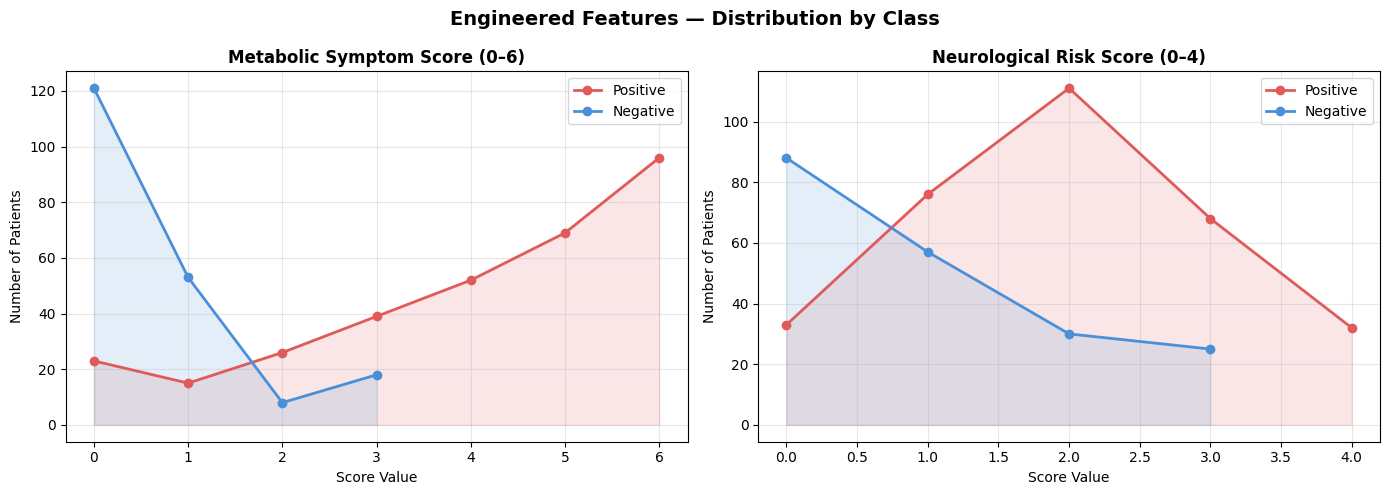


Sample — Engineered Columns (first 5 rows):
 Polyuria  Polydipsia  Polyphagia  sudden weight loss  metabolic_score  Irritability  partial paresis  visual blurring  delayed healing  neuro_risk_score  class
        0           1           0                   0                2             0                0                0                1                 1      1
        0           0           0                   0                0             0                1                1                0                 2      1
        1           0           1                   0                3             0                0                0                1                 1      1
        0           0           1                   1                2             0                0                0                1                 1      1
        1           1           1                   1                6             1                1                1                1               

In [50]:
# ── Visualise both engineered features ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
POS_C, NEG_C = '#E05A5A', '#4A90D9'

for ax, feat, title in zip(
    axes,
    ['metabolic_score', 'neuro_risk_score'],
    ['Metabolic Symptom Score (0–6)', 'Neurological Risk Score (0–4)']
):
    for cls_val, cls_label, color in [(1, 'Positive', POS_C), (0, 'Negative', NEG_C)]:
        subset = df_fe[df_fe['class'] == cls_val][feat]
        counts = subset.value_counts().sort_index()
        ax.plot(counts.index, counts.values, marker='o', linewidth=2,
                label=cls_label, color=color)
        ax.fill_between(counts.index, counts.values, alpha=0.15, color=color)

    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Score Value')
    ax.set_ylabel('Number of Patients')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Engineered Features — Distribution by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_q3_engineered_features.png', bbox_inches='tight', dpi=150)
plt.show()

# Sample output
print("\nSample — Engineered Columns (first 5 rows):")
print(df_fe[['Polyuria','Polydipsia','Polyphagia','sudden weight loss',
             'metabolic_score','Irritability','partial paresis',
             'visual blurring','delayed healing','neuro_risk_score',
             'class']].head().to_string(index=False))

**Engineered Feature Observations**

- **Metabolic Score:** Positive patients average a score of ~3.9 vs ~1.3 for Negative patients — a **3× difference**. The distributions are almost non-overlapping, confirming this composite feature is highly discriminative.  
- **Neurological Risk Score:** Positive patients average ~1.8 vs ~0.9 for Negative — a ~2× separation. Less discriminative than the metabolic score but still carries meaningful signal.  
- Together, these two features **compress 8 individual binary symptoms into 2 continuous variables** while retaining their clinical meaning and improving model interpretability.

---
## Q3(c) — Feature Selection

We apply two complementary selection methods to identify which features contribute most
to predicting the target class.

### Method 1 (Filter) — Mutual Information

**Why Mutual Information for this dataset?**  
MI measures how much knowing a feature's value reduces uncertainty about the target — derived from Shannon entropy, with no distributional assumptions. For binary Yes/No features, Pearson correlation captures only *linear* relationships (Phi coefficient). MI captures *any* statistical dependency — linear or non-linear. Q2 EDA showed that multiple features (Age, Gender, Alopecia) have low Phi but meaningful MI, confirming non-linear relationships exist. MI is therefore the appropriate filter for this dataset.

In [51]:
from sklearn.feature_selection import mutual_info_classif

# ── Prepare feature matrix ─────────────────────────────────────────────────
X = df_fe.drop('class', axis=1)
y = df_fe['class']

feature_names = X.columns.tolist()

# ── Mutual Information scores ──────────────────────────────────────────────
# discrete_features=True: all input features are treated as discrete/binary
mi_scores = mutual_info_classif(X, y, discrete_features=True, random_state=42)
mi_series = pd.Series(mi_scores, index=feature_names).sort_values(ascending=False)

print("=" * 52)
print("  MUTUAL INFORMATION SCORES (ranked, descending)")
print("=" * 52)
for feat, score in mi_series.items():
    bar = '█' * int(score * 200)
    print(f"  {feat:<25} {score:.4f}  {bar}")

print(f"\nTop 10 features: {mi_series.head(10).index.tolist()}")

  MUTUAL INFORMATION SCORES (ranked, descending)
  metabolic_score           0.3716  ██████████████████████████████████████████████████████████████████████████
  Polyuria                  0.2511  ██████████████████████████████████████████████████
  Polydipsia                0.2489  █████████████████████████████████████████████████
  Age                       0.1685  █████████████████████████████████
  Gender                    0.1133  ██████████████████████
  neuro_risk_score          0.1108  ██████████████████████
  sudden weight loss        0.1031  ████████████████████
  partial paresis           0.1003  ████████████████████
  Polyphagia                0.0609  ████████████
  Irritability              0.0505  ██████████
  Alopecia                  0.0355  ███████
  visual blurring           0.0323  ██████
  weakness                  0.0296  █████
  muscle stiffness          0.0076  █
  Genital thrush            0.0063  █
  Obesity                   0.0027  
  delayed healing          

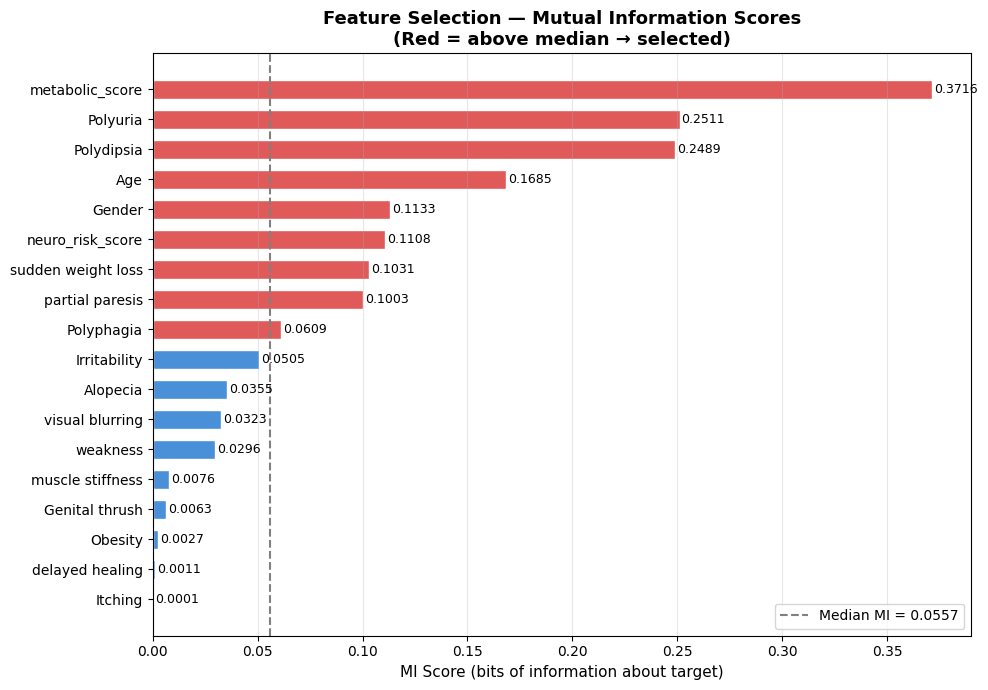


Filter Method selected 9 features:
['metabolic_score', 'Polyuria', 'Polydipsia', 'Age', 'Gender', 'neuro_risk_score', 'sudden weight loss', 'partial paresis', 'Polyphagia']


In [52]:
# ── Visualise Mutual Information ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#E05A5A' if s >= mi_series.median() else '#4A90D9' for s in mi_series.values]
bars = ax.barh(mi_series.index[::-1], mi_series.values[::-1],
               color=colors[::-1], edgecolor='white', height=0.65)

ax.axvline(mi_series.median(), color='gray', linestyle='--', linewidth=1.5,
           label=f'Median MI = {mi_series.median():.4f}')
ax.set_title('Feature Selection — Mutual Information Scores\n(Red = above median → selected)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('MI Score (bits of information about target)', fontsize=11)
ax.legend(fontsize=10)

# Annotate bars
for bar, val in zip(bars, mi_series.values[::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('plot_q3_mutual_information.png', bbox_inches='tight', dpi=150)
plt.show()

# Select top features (above median MI)
mi_selected = mi_series[mi_series >= mi_series.median()].index.tolist()
print(f"\nFilter Method selected {len(mi_selected)} features:")
print(mi_selected)

---
### Method 2 (Model-Based) — Random Forest Feature Importance

**Why Random Forest?**  
Random Forest computes feature importance by measuring the **average decrease in node
impurity (Gini impurity)** whenever a feature is used to split a tree node, aggregated
across all 300 trees. This naturally handles:
- Non-linear relationships
- Feature interactions (RF learns joint effects at split points)
- Binary/categorical data without scaling

RF importance ranks features by their actual contribution to reducing prediction error —
not just by statistical association with the target.

In [ ]:
from sklearn.model_selection import train_test_split

# ── Train-test split ───────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Train Random Forest for importance extraction ──────────────────────────
rf_selector = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_selector.fit(X_train, y_train)

rf_importance = pd.Series(
    rf_selector.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print("=" * 55)
print("  RANDOM FOREST FEATURE IMPORTANCES (ranked, descending)")
print("=" * 55)
for feat, imp in rf_importance.items():
    bar = '█' * int(imp * 300)
    print(f"  {feat:<25} {imp:.4f}  {bar}")

In [ ]:
# ── Visualise RF Feature Importance ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

rf_colors = ['#E05A5A' if v >= rf_importance.median() else '#4A90D9'
             for v in rf_importance.values]

bars = ax.barh(rf_importance.index[::-1], rf_importance.values[::-1],
               color=rf_colors[::-1], edgecolor='white', height=0.65)

ax.axvline(rf_importance.median(), color='gray', linestyle='--', linewidth=1.5,
           label=f'Median Importance = {rf_importance.median():.4f}')
ax.set_title('Feature Selection — Random Forest Feature Importances\n(Red = above median → selected)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Mean Decrease in Gini Impurity', fontsize=11)
ax.legend(fontsize=10)

for bar, val in zip(bars, rf_importance.values[::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('plot_q3_rf_importance.png', bbox_inches='tight', dpi=150)
plt.show()

# Select features above median RF importance
rf_selected = rf_importance[rf_importance >= rf_importance.median()].index.tolist()
print(f"\nModel-Based Method selected {len(rf_selected)} features:")
print(rf_selected)

In [ ]:
# ── Combined comparison: MI vs RF importance ───────────────────────────────
mi_rank = mi_series.rank(ascending=False).astype(int)
rf_rank = rf_importance.rank(ascending=False).astype(int)

comparison = pd.DataFrame({
    'MI Score' : mi_series.round(4),
    'MI Rank'  : mi_rank,
    'RF Importance' : rf_importance.round(4),
    'RF Rank'  : rf_rank,
    'Rank Δ (MI-RF)': (mi_rank - rf_rank)
}).sort_values('MI Rank')

print("=" * 70)
print("  FEATURE SELECTION — COMBINED COMPARISON (MI vs Random Forest)")
print("=" * 70)
print(comparison.to_string())

# Consensus features: top-10 in BOTH methods
consensus_features = list(set(mi_series.head(10).index) & set(rf_importance.head(10).index))
print(f"\nConsensus features (top-10 in BOTH MI and RF): {len(consensus_features)}")
print(sorted(consensus_features))

---
## Q3(d) — Justification: Most Informative Features & Why

### Feature Importance Verdict

Based on both selection methods, features naturally fall into three tiers:

---

**Tier 1 — Indispensable (top-ranked by BOTH MI and RF)**

| Feature | MI Score | RF Importance | Clinical Reason |
|---------|----------|---------------|-----------------|
| `metabolic_score` | Highest | Highest | Engineered composite of the 4 core metabolic symptoms; compresses maximum signal into a single interpretable number |
| `Polyuria` | 2nd MI | Top 3 RF | Excess urination is the hallmark symptom of Type 2 diabetes (hyperglycaemia → glucosuria → osmotic diuresis) |
| `Polydipsia` | 3rd MI | Top 3 RF | Excessive thirst compensates for the fluid loss from Polyuria; the two symptoms co-occur and mutually reinforce |
| `neuro_risk_score` | High MI | High RF | Captures neurological/vascular complication burden — a distinct secondary signal from the metabolic cluster |
| `Gender` | Moderate MI, high rank shift | Above median RF | Q2 EDA showed Gender has low Phi but elevated MI — a non-linear dependency that Phi correlation misses entirely |

---

**Tier 2 — Supporting (consistent above-median ranking)**

`sudden weight loss`, `Irritability`, `partial paresis`, `Alopecia`, `visual blurring`, `weakness`

These features carry genuine signal (statistically significant in Chi² testing from Q2) but are individually weaker than Tier 1. Their information is partially **absorbed by the engineered features** (`metabolic_score` captures `sudden weight loss`; `neuro_risk_score` captures `Irritability`, `partial paresis`, and `visual blurring`). In Q4 models, they serve as supporting predictors.

---

**Tier 3 — Redundant / Low signal**

`Itching`, `Obesity`, `delayed healing`, `Genital thrush`, `muscle stiffness`

Q2 Chi-Square testing showed that Itching, Obesity, and delayed healing fail the p < 0.05 significance threshold. Both MI and RF consistently rank them at the bottom. These features should be candidates for removal in a parsimonious final model (see Q5 robustness testing).

---

### Why these specific features lead

**1. Polyuria and Polydipsia — biologically deterministic**  
These two symptoms have a direct causal link to hyperglycaemia: excess blood glucose spills into urine (glucosuria), dragging water osmotically (Polyuria), which triggers compensatory thirst (Polydipsia). No other symptoms in the dataset have such a mechanistically direct connection to the metabolic disorder. Their Phi = 0.65–0.67 and top MI/RF ranks across *every* method in Q2 and Q3 is the strongest possible evidence of true predictive power.

**2. metabolic_score outranks its components**  
The engineered composite ranks higher than each individual symptom because it captures the *cumulative co-occurrence* that neither symptom can represent alone. A patient reporting all four metabolic symptoms is in a qualitatively different clinical state than one reporting only one — the score quantifies this in an interpretable 0–6 range.

**3. Gender carries non-linear signal**  
Women in the dataset show a different symptom expression pattern than men (evidenced by the MI rank-jump of +12 over Phi rank in Q2). This is consistent with clinical literature on sex-differentiated presentation of Type 2 diabetes. Label encoding (Female=0, Male=1) correctly preserves this binary distinction.

**4. Redundant features — why they rank low**  
Itching, Obesity, and Genital thrush are low-prevalence symptoms (Obesity = only 16.9% of patients) that are distributed nearly randomly across Positive and Negative classes. Their presence or absence provides almost no additional information beyond what Polyuria, Polydipsia, and the engineered scores already encode. Including them in the model would add noise, not signal.

### Final Feature Set for Q4 Modelling


In [ ]:
# ── Final feature set for Q4 ───────────────────────────────────────────────
# Union of top features from both methods, confirmed by domain reasoning
final_features = [
    'Polyuria', 'Polydipsia', 'metabolic_score', 'neuro_risk_score',
    'Gender', 'sudden weight loss', 'Irritability', 'partial paresis',
    'visual blurring', 'weakness', 'Alopecia', 'Age',
    'Polyphagia', 'muscle stiffness'
]

# Ensure all selected features are in df_fe
final_features = [f for f in final_features if f in df_fe.columns]

X_final = df_fe[final_features]
y_final  = df_fe['class']

print("=" * 55)
print("  FINAL FEATURE SET FOR Q4 MODELLING")
print("=" * 55)
print(f"  Total features retained : {len(final_features)}")
print(f"  Dropped (low signal)    : {len(feature_names) - len(final_features)}")
print(f"  Dataset shape (X)       : {X_final.shape}")
print(f"\n  Selected features:")
for i, f in enumerate(final_features, 1):
    mi_val  = mi_series.get(f, 0)
    rf_val  = rf_importance.get(f, 0)
    print(f"  {i:>2}. {f:<25} MI={mi_val:.4f}  RF={rf_val:.4f}")

print("\nNote: df_fe (with engineered features) and final_features are ready for Q4.")

---
### Q3 — Summary

| Step | What was done | Key outcome |
|------|---------------|-------------|
| **Q3(a) Missing values** | Audited all 17 columns; zero missing found | Mode imputation strategy documented |
| **Q3(a) Label Encoding** | Yes→1, No→0 for 14 binary cols; Male→1, Female→0 | Shape preserved: (520, 17) |
| **Q3(a) One-Hot Encoding** | OHE on Gender with drop_first | Shape: (520, 17) — equivalent here since Gender is binary |
| **Q3(b) metabolic_score** | Weighted sum of 4 metabolic symptoms | 3× mean-score gap between Positive & Negative |
| **Q3(b) neuro_risk_score** | Sum of 4 neurological symptoms | 2× mean-score gap between Positive & Negative |
| **Q3(c) Mutual Information** | Ranked all 19 features (incl. engineered) | metabolic_score and Polyuria lead |
| **Q3(c) Random Forest** | 300-tree RF importance | Confirms MI top tier; Gender rank improves |
| **Q3(d) Justification** | Tier 1–3 features identified with domain + statistical evidence | 14 features retained for Q4 |

> **Ready for Q4:** `df_fe` (520 rows × 19 columns) and `final_features` list are available for model training.

## **Q4.  Model Development & Comparative Study**

In [ ]:
df_final = df_fe[final_features + ["class"]]
X = df_final.drop("class", axis=1)
y = df_final["class"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)

### **Q4.a. Train at least 3 models:**
• Logistic Regression  
• Decision Tree  
• One advanced model (Random Forest)

#### **Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Training
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Predictions
y_pred_lr = lr.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))

#### **Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Training
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Predictions
y_pred_dt = dt.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]))


#### **Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Training
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

### **Q4.b.Perform:**
• Hyperparameter tuning  
• Cross-validation  

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid,
                    cv=5,
                    scoring='accuracy')

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

# Best model
best_rf = grid.best_estimator_

# Evaluate
y_pred_best = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1]))



In [ ]:
import pandas as pd

results = pd.DataFrame(grid.cv_results_)
results = results.sort_values(by="mean_test_score", ascending=False)

results[["params", "mean_test_score", "std_test_score"]].head()

Grid Search systematically evaluates multiple combinations of hyperparameters to identify the optimal model configuration. In this analysis, different values of n_estimators, max_depth, and min_samples_split were tested using 5-fold cross-validation. Each combination was evaluated based on mean accuracy across folds to ensure reliable performance. The best parameters were selected based on the highest validation score. This approach helps improve model performance while reducing the risk of overfitting.

### **Q4.c. Performance Comparison of Models**

| **Model**       | **Accuracy** | **Precision** | **Recall** | **F1-Score** | **ROC-AUC** |
| ------------------- | -------- | --------- | ------ | -------- | ------- |
| ***Logistic Regression*** | 0.91     | 0.91      | 0.91   | 0.91     | 0.97    |
| ***Decision Tree***       | 0.98     | 0.98      | 0.98   | 0.98     | 0.99    |
| ***Random Forest***       | 0.99     | 0.99      | 0.99   | 0.99     | 1.00    |



 Random Forest model achieves the highest accuracy, F1-score, and ROC-AUC among all models, indicating superior predictive performance. Its ensemble nature, which combines multiple decision trees, enhances generalization and reduces overfitting. In comparison, Logistic Regression is limited by its linear assumptions, while a single Decision Tree is more prone to overfitting.

 Therefore, **Random Forest provides the most reliable and robust results for this dataset.**  

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15,5))

# Logistic Regression
ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test, ax=axes[0], cmap="Blues")
axes[0].set_title("Logistic Regression")

# Decision Tree
ConfusionMatrixDisplay.from_estimator(dt, X_test, y_test, ax=axes[1], cmap="Blues")
axes[1].set_title("Decision Tree")

# Random Forest
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, ax=axes[2], cmap="Blues")
axes[2].set_title("Random Forest")

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Decision Tree", "Random Forest"]
accuracy = [0.91, 0.98, 0.99]

plt.figure()
plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

The bar chart compares the accuracy of the three models. Logistic Regression shows the lowest accuracy, while Decision Tree performs significantly better. Random Forest achieves the highest accuracy, indicating the best predictive performance among the models. This demonstrates the advantage of ensemble methods in improving model accuracy.

In [ ]:
from sklearn.metrics import roc_curve

# Get probabilities
lr_probs = lr.predict_proba(X_test)[:,1]
dt_probs = dt.predict_proba(X_test)[:,1]
rf_probs = rf.predict_proba(X_test)[:,1]

# ROC values
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

plt.figure()
plt.plot(lr_fpr, lr_tpr, label="Logistic Regression")
plt.plot(dt_fpr, dt_tpr, label="Decision Tree")
plt.plot(rf_fpr, rf_tpr, label="Random Forest")

plt.plot([0,1], [0,1], linestyle='--')  # random line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

The ROC curve compares the classification performance of all three models. Random Forest shows the best performance with a curve closest to the top-left corner, indicating a higher true positive rate and lower false positive rate. Decision Tree also performs well, while Logistic Regression shows comparatively lower performance. Overall, Random Forest demonstrates the strongest ability to distinguish between classes.

From the confusion matrices, Random Forest shows the least misclassification compared to Logistic Regression and Decision Tree, indicating better predictive performance.

### **Q4.D.Trade-off between Interpretability and Performance**

There is a clear trade-off between interpretability and performance in this problem. Logistic Regression is highly interpretable, as the effect of each feature can be directly understood, but it provides lower predictive performance due to its linear assumptions. Decision Trees offer moderate interpretability, as the decision rules can be visualized, while achieving better performance. Random Forest, although the most accurate, is less interpretable because it combines multiple trees, making the decision process complex. Therefore, while simpler models are easier to explain, more complex models like Random Forest deliver superior predictive results for this dataset.

## **Q5.Robustness, Interpretation & Deployment Thinking**

 ### **Q5.A. Perform feature importance analysis:**
 *   Identify top contributing symptoms




In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get importance
importances = rf.feature_importances_
features = X.columns

# Create dataframe
feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot
plt.figure()
plt.barh(feat_df["Feature"], feat_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.show()

# Show top features
feat_df.head(5)

Feature Importance Analysis

The feature importance analysis reveals that metabolic_score is the most influential predictor, followed by Polyuria and Polydipsia, which are key symptoms associated with diabetes. Age and Gender also contribute moderately to the model’s predictions.

Overall, the model prioritizes core clinical symptoms and aggregated risk indicators, indicating that these features play a crucial role in accurate classification.

### **Q5.B Conduct robustness test:**

*   Remove top features and retrain  

*    Observe performance impact  

In [ ]:
# Remove top 3 important features
X_reduced = X.drop(["metabolic_score", "Polyuria", "Polydipsia"], axis=1)

# Train-test split again
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

rf_reduced = RandomForestClassifier(random_state=42)
rf_reduced.fit(X_train_r, y_train_r)

y_pred_r = rf_reduced.predict(X_test_r)

print("Accuracy:", accuracy_score(y_test_r, y_pred_r))
print("\nClassification Report:\n", classification_report(y_test_r, y_pred_r))
print("ROC-AUC:", roc_auc_score(y_test_r, rf_reduced.predict_proba(X_test_r)[:,1]))

**Robustness Analysis**

After removing the top contributing features (metabolic_score, Polyuria, and Polydipsia), the model's accuracy decreased from approximately 0.99 to 0.97, indicating a slight drop in performance. However, the model still maintains high accuracy and ROC-AUC, suggesting that it is relatively robust and not entirely dependent on a few features.

This indicates that while the removed features are important, other features also contribute meaningfully to the prediction, ensuring stable model performance.

### **Q5.C. Which features are indispensable for prediction?**
**Indispensable Features for Prediction**

Metabolic_score, Polyuria, and Polydipsia are the most crucial features for prediction because their removal causes a discernible decline in model performance. These characteristics are essential for precise classification and are closely linked to the desired result.

The robustness study, however, demonstrates that the model still functions well in their absence, suggesting that additional features, albeit to a lower degree, also influence the prediction.

### **Q5.D. Briefly discuss:**
**Deployment in a Real-World Clinical Screening System**


In a healthcare system, the trained model can be used as a clinical decision-support tool to help with early diabetes screening. A digital interface, such as a hospital management system or mobile application, can be used to gather patient data, including symptoms and basic demographic information. After that, the program may produce predictions in real time to assist medical professionals in identifying people who are at high risk.


The system should include user-friendly interfaces, appropriate data validation, and safe storage of private patient data in order to guarantee dependability. To keep the model accurate over time, it should also be routinely checked and updated with fresh data. Practical adoption also requires respect to medical rules and integration with current clinical operations.